# Google Play Store Analytics Project

**Project Goals**
- Understand factors affecting app ratings
- Perform sentiment analysis on user reviews
- Build a predictive model for app ratings

We are taking a step-by-step approach ensuring data validation and clarity at each stage.

## Table of Contents

- [Google Play Store Analytics Project](#google-play-store-analytics-project)
  - [Step 1: Initialization and Data Loading](#step-1-initialization-and-data-loading)
    - [3. Display Initial Data Configurations](#3-display-initial-data-configurations)
    - [4. Understand Structure Summaries](#4-understand-structure-summaries)
  - [Step 2: Data Cleaning - Handling Missing Values](#step-2-data-cleaning---handling-missing-values)
    - [Cleaning Strategy](#cleaning-strategy)
  - [Step 3: Data Type Conversions](#step-3-data-type-conversions)
  - [Step 4: Remove Duplicates](#step-4-remove-duplicates)
  - [Step 5: Combine Datasets](#step-5-combine-datasets)
  - [Step 6: Exploratory Data Analysis (Univariate Analysis)](#step-6-exploratory-data-analysis-univariate-analysis)
  - [Step 7: Analyze Categorical Variables](#step-7-analyze-categorical-variables)
  - [Step 8: Bivariate Analysis (Variable Relationships)](#step-8-bivariate-analysis-variable-relationships)
  - [Step 9: Interactive Visualizations (Plotly)](#step-9-interactive-visualizations-plotly)
- [Standard EDA Dashboard](#standard-eda-dashboard-10-charts)
  - [Step 10: Feature Engineering](#step-10-feature-engineering)
  - [Step 11: NLP Preprocessing (Text Cleaning)](#step-11-nlp-preprocessing-text-cleaning)
  - [Step 12: VADER Sentiment Analysis](#step-12-vader-sentiment-analysis)
  - [Step 13: Aggregate Sentiment to App Level](#step-13-aggregate-sentiment-to-app-level)
  - [Step 14: Sentiment vs. Rating Analysis](#step-14-sentiment-vs-rating-analysis)
  - [Step 15: Predictive Modeling (Random Forest Regressor)](#step-15-predictive-modeling-random-forest-regressor)
  - [Step 16: Model Evaluation & Feature Importance](#step-16-model-evaluation-&-feature-importance)
  - [Step 17: Key Insights & Business Recommendations](#step-17-key-insights-&-business-recommendations)
    - [Exploratory Data Analysis Findings](#exploratory-data-analysis-findings)
    - [Sentiment Analysis Findings](#sentiment-analysis-findings)
    - [Predictive Model Highlights (Random Forest)](#predictive-model-highlights-random-forest)
    - [Business Recommendations](#business-recommendations)
  - [Conclusion](#conclusion)
- [Internship Tasks](#internship-tasks)
    - [Task 1: Grouped Bar Chart — Avg Rating & Total Reviews for Top 10 Categories by Installs](#task-1-grouped-bar-chart-—-avg-rating-&-total-reviews-for-top-10-categories-by-installs)
    - [Task 2: Interactive Choropleth-Style Map — Installs by Category](#task-2-interactive-choropleth-style-map-—-installs-by-category)
    - [Task 3: Dual-Axis Chart — Avg Installs & Revenue for Free vs Paid (Top 3 Categories)](#task-3-dual-axis-chart-—-avg-installs-&-revenue-for-free-vs-paid-top-3-categories)
    - [Task 4: Time Series — Monthly Installs by Category with Growth Highlighting](#task-4-time-series-—-monthly-installs-by-category-with-growth-highlighting)
    - [Task 5: Bubble Chart — Size vs Rating (Bubble Size = Installs)](#task-5-bubble-chart-—-size-vs-rating-bubble-size-=-installs)
    - [Task 6: Stacked Area Chart — Cumulative Installs Over Time](#task-6-stacked-area-chart-—-cumulative-installs-over-time)
- [Internship Tasks — Insights & Conclusion](#internship-tasks-—-insights-&-conclusion)


## Step 1: Initialization and Data Loading

In this section, we will:
1. Import the fundamental libraries (pandas, numpy).
2. Load our raw datasets.
3. Perform preliminary data inspection (shape, columns, head).
4. Check for data types and missing values using `.info()` and descriptive statistics using `.describe()`.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# %pip install pandas numpy matplotlib seaborn plotly nltk scikit-learn
import pandas as pd
import numpy as np

print("Libraries successfully imported.")

Libraries successfully imported.


In [ ]:

apps_df = pd.read_csv('Play Store Data.csv')
reviews_df = pd.read_csv('User Reviews.csv')

print("Datasets successfully loaded.")

Datasets successfully loaded.


### 3. Display Initial Data Configurations
We need to understand the structural properties of our dataset, including the number of observations and variables, as well as what those variables are named.

In [ ]:
# Display dataset shapes to know observation/feature count
print("--- Data Shapes ---")
print(f"Apps dataset shape: {apps_df.shape[0]} rows, {apps_df.shape[1]} columns")
print(f"Reviews dataset shape: {reviews_df.shape[0]} rows, {reviews_df.shape[1]} columns")
print("\n")

# Display column names to understand feature availability
print("--- Column Names ---")
print(f"Apps columns: {apps_df.columns.tolist()}\n")
print(f"Reviews columns: {reviews_df.columns.tolist()}")

--- Data Shapes ---
Apps dataset shape: 10841 rows, 13 columns
Reviews dataset shape: 64295 rows, 5 columns


--- Column Names ---
Apps columns: ['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

Reviews columns: ['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']


Let's visually inspect the first 5 rows of each dataset to confirm everything aligns properly.

In [ ]:

display(apps_df.head(5))

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:

display(reviews_df.head(5))

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


### 4. Understand Structure Summaries
Using `.info()` gives us a rundown of data types and null presence, while `.describe()` provides a statistical perspective (useful especially for numeric fields).

In [ ]:
apps_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


In [ ]:
display(apps_df.describe(include='all'))

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,10841,10841,9367.000000,10841,10841,10841,10840,10841,10840,10841,10841,10833,10838
unique,9660,34,NaN,6002,462,22,3,93,6,120,1378,2832,33
top,ROBLOX,FAMILY,NaN,0,Varies with device,"1,000,000+",Free,0,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up
freq,9,1972,NaN,596,1695,1579,10039,10040,8714,842,326,1459,2451
mean,NaN,NaN,4.193338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,0.537431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,4.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,4.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:

reviews_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  str    
 1   Translated_Review       37427 non-null  str    
 2   Sentiment               37432 non-null  str    
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), str(3)
memory usage: 2.5 MB


In [ ]:

display(reviews_df.describe(include='all'))

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
count,64295,37427,37432,37432.000000,37432.000000
unique,1074,27994,3,NaN,NaN
top,Angry Birds Classic,Good,Positive,NaN,NaN
freq,320,247,23998,NaN,NaN
mean,NaN,NaN,NaN,0.182146,0.492704
std,NaN,NaN,NaN,0.351301,0.259949
min,NaN,NaN,NaN,-1.000000,0.000000
25%,NaN,NaN,NaN,0.000000,0.357143
50%,NaN,NaN,NaN,0.150000,0.514286
75%,NaN,NaN,NaN,0.400000,0.650000


## Step 2: Data Cleaning - Handling Missing Values

Before diving into insights, we need to address any gaps in our data. Missing values can skew analysis or cause machine learning models to fail.

We'll identify missing values and decide whether to fill them (imputation) or drop them based on their impact.

In [10]:
# 1. Identify missing values using isnull().sum()
print("--- Missing Values: Apps Dataset ---")
display(apps_df.isnull().sum())

print("\n--- Missing Values: Reviews Dataset ---")
display(reviews_df.isnull().sum())

--- Missing Values: Apps Dataset ---


App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


--- Missing Values: Reviews Dataset ---


App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

### Cleaning Strategy
- **Apps `Rating`**: Ratings are our target variable for predictive modeling. We cannot train models on missing targets, so we must drop these rows.
- **Apps `Size`**: Missing sizes will be replaced with `'Varies with device'`, matching the existing taxonomy in this dataset and avoiding data loss.
- **Apps `Reviews`**: A critical numeric indicator. Without reviews, engagement cannot be judged. Any missing rows here will be dropped.
- **Reviews `Translated_Review`**: If the review text itself is missing, sentiment analysis is impossible. We will drop these rows.

In [ ]:

apps_original_shape = apps_df.shape
reviews_original_shape = reviews_df.shape

apps_df.dropna(subset=['Rating'], inplace=True)

apps_df.fillna({'Size': 'Varies with device'}, inplace=True)

apps_df.dropna(subset=['Reviews'], inplace=True)

apps_df.dropna(subset=['Type', 'Content Rating', 'Current Ver', 'Android Ver'], inplace=True)

reviews_df.dropna(subset=['Translated_Review'], inplace=True)

reviews_df.dropna(subset=['Sentiment'], inplace=True)

In [ ]:

print("--- Data Retention Summary ---")
print(f"Apps dataset shape went from {apps_original_shape} to {apps_df.shape}")
print(f"Apps retention rate: {round(apps_df.shape[0]/apps_original_shape[0]*100, 2)}%")

print(f"\nReviews dataset shape went from {reviews_original_shape} to {reviews_df.shape}")
print(f"Reviews retention rate: {round(reviews_df.shape[0]/reviews_original_shape[0]*100, 2)}%\n")

print("--- Remaining Missing Values (Apps) ---")
display(apps_df.isnull().sum())

print("\n--- Remaining Missing Values (Reviews) ---")
display(reviews_df.isnull().sum())

--- Data Retention Summary ---
Apps dataset shape went from (10841, 13) to (9360, 13)
Apps retention rate: 86.34%

Reviews dataset shape went from (64295, 5) to (37427, 5)
Reviews retention rate: 58.21%

--- Remaining Missing Values (Apps) ---


App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64


--- Remaining Missing Values (Reviews) ---


App                       0
Translated_Review         0
Sentiment                 0
Sentiment_Polarity        0
Sentiment_Subjectivity    0
dtype: int64

## Step 3: Data Type Conversions

Currently, several numerical columns (Reviews, Size, Installs, Price) are stored as strings (objects) because they contain special characters like `M`, `k`, `+`, or `$`. 
To perform statistical and mathematical operations, we need these in proper numeric formats.

We will define reusable helper functions for the complex conversions to keep our logic clean and readable.

In [ ]:
import numpy as np

def clean_size(size_str):
    """
    Converts string sizes like '19M' and '20k' into a uniform numeric float representing Megabytes (MB).
    Handles 'Varies with device' by returning NaN so it doesn't break mathematical models.
    """
    if pd.isna(size_str) or size_str == 'Varies with device':
        return np.nan
    
    size_str = str(size_str).upper()
    
    try:
        if 'M' in size_str:
            return float(size_str.replace('M', ''))
        elif 'K' in size_str:
        
            return float(size_str.replace('K', '')) / 1024.0
        elif size_str == '1,000+': # Play store edge case where size is mistakenly numeric installs format
            return np.nan
        else:
            # Fallback if no M or K is found
            return float(size_str)
    except ValueError:
        return np.nan

def clean_installs(installs_str):
    """
    Strips commas and plus signs from install strings like '1,000,000+' and converts to integer.
    """
    if pd.isna(installs_str):
        return np.nan
    
    clean_str = str(installs_str).replace('+', '').replace(',', '')
    
    try:
        return int(clean_str)
    except ValueError:
        return np.nan

In [ ]:
# 1. Convert Reviews to numeric
apps_df['Reviews'] = pd.to_numeric(apps_df['Reviews'], errors='coerce')

# 2. Convert Size to numeric (Megabytes) using our helper function
apps_df['Size_MB'] = apps_df['Size'].apply(clean_size)
# We can drop the original string 'Size' column now that we have a clean numeric version.
apps_df.drop('Size', axis=1, inplace=True)

# 3. Convert Installs to numeric using our helper function
apps_df['Installs'] = apps_df['Installs'].apply(clean_installs)

# 4. Convert Price to float (remove '$' symbol)
apps_df['Price'] = apps_df['Price'].astype(str).str.replace('$', '', regex=False)
apps_df['Price'] = pd.to_numeric(apps_df['Price'], errors='coerce')

In [15]:
# Check for unintentional NaNs created during conversion by capturing sum before and after
print("--- Validation: Missing values after conversion ---")
validation_cols = ['Reviews', 'Size_MB', 'Installs', 'Price']
display(apps_df[validation_cols].isnull().sum())

print("\n(Note: 'Size_MB' missing values correspond to 'Varies with device' which we safely translated to NaN for now)")

--- Validation: Missing values after conversion ---


Reviews        0
Size_MB     1637
Installs       0
Price          0
dtype: int64


(Note: 'Size_MB' missing values correspond to 'Varies with device' which we safely translated to NaN for now)


In [16]:
# Final DataType verification
print("\n--- Verification: Data Types ---")
display(apps_df[validation_cols].dtypes)


--- Verification: Data Types ---


Reviews       int64
Size_MB     float64
Installs      int64
Price       float64
dtype: object

## Step 4: Remove Duplicates

Play Store datasets often scrape the same app multiple times (e.g., across different categories). We need a single source of truth for each app.

Our strategy is to identify duplicates based on the `App` name. To keep the most relevant entry, we will sort the apps by `Reviews` descending so the record with the most engagement (usually the most updated one) is kept while the rest are dropped.

In [17]:
# 1. Identify total number of duplicates before removal
duplicate_count = apps_df.duplicated(subset=['App']).sum()
print(f"--- Duplicate Apps Detected ---")
print(f"Total duplicated app rows: {duplicate_count}")

--- Duplicate Apps Detected ---
Total duplicated app rows: 1170


In [ ]:
apps_df = apps_df.sort_values(by=['App', 'Reviews'], ascending=[True, False])

apps_df.drop_duplicates(subset=['App'], keep='first', inplace=True)

print("Duplicates safely removed.")

Duplicates safely removed.


In [19]:
# 3. Validation: Confirm no duplicate app names remain
remaining_duplicates = apps_df.duplicated(subset=['App']).sum()
print(f"--- Validation ---")
print(f"Remaining duplicate app names: {remaining_duplicates}")
print(f"Final Apps dataset size: {apps_df.shape[0]} rows")

--- Validation ---
Remaining duplicate app names: 0
Final Apps dataset size: 8190 rows


## Step 5: Combine Datasets

To perform holistic analysis combining app metadata with user sentiment, we need to merge our `apps_df` with our `reviews_df`.

**Merge Strategy:** We will use a `left` join, leveraging `apps_df` as our primary table. This ensures we retain all verified apps in our database even if they don't happen to have corresponding scraped user reviews in the secondary dataset.

In [ ]:
merged_df = apps_df.merge(reviews_df, on='App', how='left')

In [ ]:

print("--- Final Merge Validation ---")
print(f"Original Apps dataset size: {apps_df.shape}")
print(f"Original Reviews dataset size: {reviews_df.shape}")
print(f"Merged dataset size: {merged_df.shape}\n")

unique_apps_original = apps_df['App'].nunique()
unique_apps_merged = merged_df['App'].nunique()

print(f"Unique apps in original: {unique_apps_original}")
print(f"Unique apps in merged:   {unique_apps_merged}")
if unique_apps_original == unique_apps_merged:
    print("Success: No unique apps were unexpectedly lost or invented during the merge.")

display(merged_df.head(3))

--- Final Merge Validation ---
Original Apps dataset size: (8190, 13)
Original Reviews dataset size: (37427, 5)
Merged dataset size: (43303, 17)

Unique apps in original: 8190
Unique apps in merged:   8190
Success: No unique apps were unexpectedly lost or invented during the merge.


,App,Category,Rating,Reviews,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,+Download 4 Instagram Twitter,SOCIAL,4.5,40467,1000000,Free,0.0,Everyone,Social,"August 2, 2018",5.03,4.1 and up,22.000000,NaN,NaN,NaN,NaN
1,- Free Comics - Comic Apps,COMICS,3.5,115,10000,Free,0.0,Mature 17+,Comics,"July 13, 2018",5.0.12,5.0 and up,9.100000,NaN,NaN,NaN,NaN
2,.R,TOOLS,4.5,259,10000,Free,0.0,Everyone,Tools,"September 16, 2014",1.1.06,1.5 and up,0.198242,NaN,NaN,NaN,NaN


## Step 6: Exploratory Data Analysis (Univariate Analysis)

Before building any models, we need to understand the underlying distributions of our key metrics. 
We will analyze `apps_df` (not the merged dataset) to ensure an app's metrics aren't artificially boosted simply because it has multiple rows linked to different user reviews.

We will plot the distributions for: `Rating`, `Reviews`, and `Installs`.

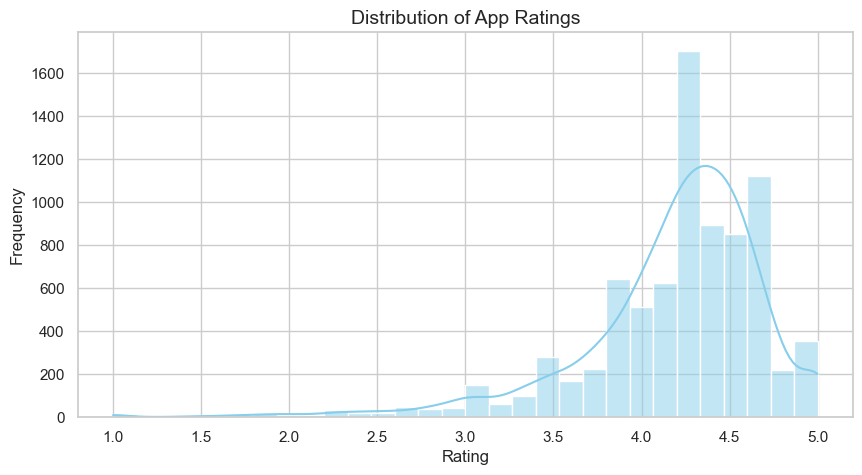

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

# 1. Plot Distribution of App Ratings
plt.figure(figsize=(10, 5))
sns.histplot(apps_df['Rating'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Distribution of App Ratings', fontsize=14)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

**Insight (Rating):** The distribution is highly skewed to the left. The vast majority of apps maintain a rating between 4.0 and 4.7. This indicates that extreme low ratings are rare or those apps don't survive long on the store. Our predictive model will need to account for this class imbalance (most data is inherently positive).

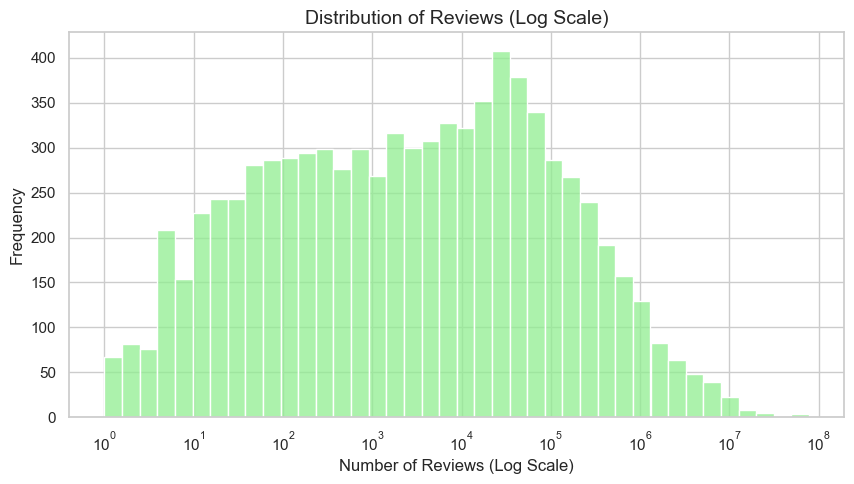

In [ ]:
# 2. Plot Distribution of Reviews
plt.figure(figsize=(10, 5))
sns.histplot(apps_df['Reviews'].dropna(), bins=40, log_scale=True, color='lightgreen')
plt.title('Distribution of Reviews (Log Scale)', fontsize=14)
plt.xlabel('Number of Reviews (Log Scale)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

**Insight (Reviews):** Review counts span several orders of magnitude. Using a logarithmic scale reveals a more balanced curve, but linear plotting would show a massive spike at zero. Most apps have nominal reviews, while a select few "mega-apps" hold millions.

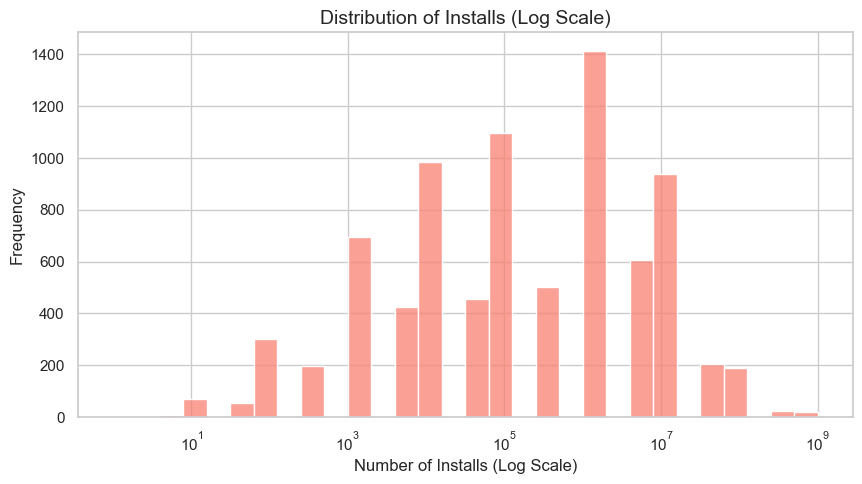

In [24]:
# 3. Plot Distribution of Installs
plt.figure(figsize=(10, 5))
sns.histplot(apps_df['Installs'].dropna(), bins=30, log_scale=True, color='salmon')
plt.title('Distribution of Installs (Log Scale)', fontsize=14)
plt.xlabel('Number of Installs (Log Scale)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

**Insight (Installs):** Like reviews, installs follow a power-law distribution. You can vividly see the "bucketing" nature of Play Store install categories indicated by the sharp separated spikes (e.g., discrete jumps from 1M to 5M). Very few apps break the 100M+ barrier.

## Step 7: Analyze Categorical Variables

Next, we examine the categorical metadata of our applications, specifically the `Category` and `Content Rating`. 
By looking at the frequencies of these classes, we can ascertain target demographics and observe market saturation.

In [ ]:
apps_df['Category'] = apps_df['Category'].str.strip().str.upper()
apps_df['Content Rating'] = apps_df['Content Rating'].str.strip()

category_counts = apps_df['Category'].value_counts()

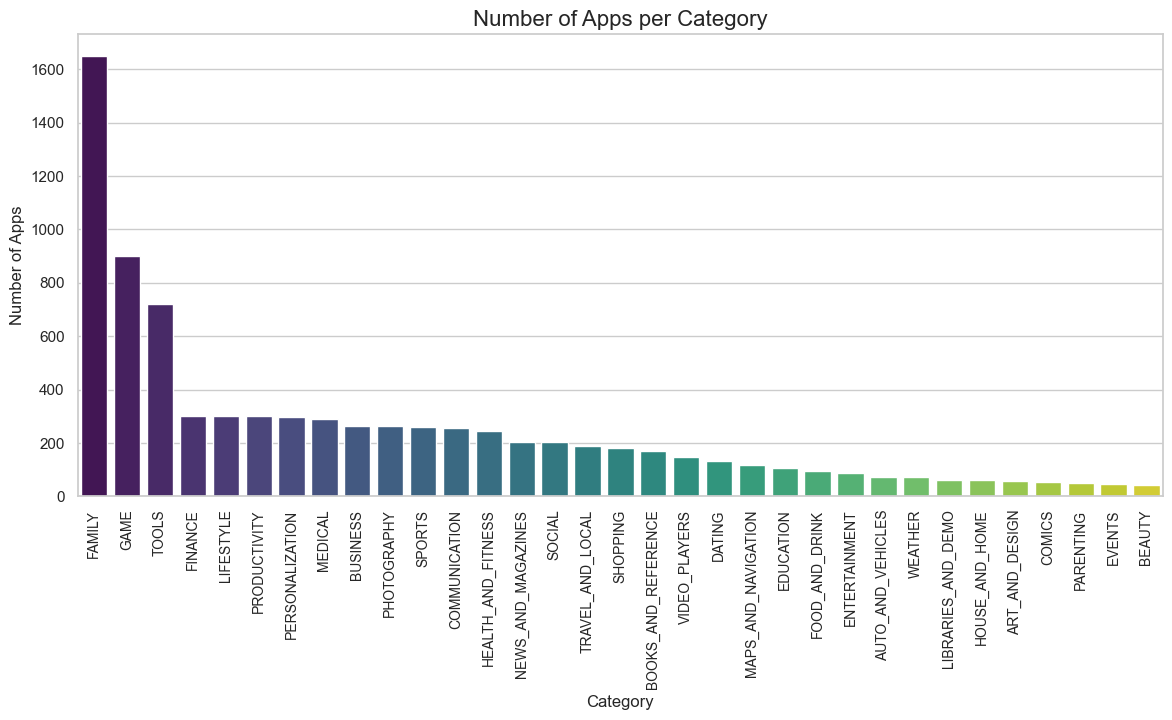

In [ ]:
# 2a. Plot Number of apps per Category
plt.figure(figsize=(14, 6))
sns.barplot(x=category_counts.index, y=category_counts.values, hue=category_counts.index, legend=False, palette="viridis")

plt.xticks(rotation=90, fontsize=10)
plt.title('Number of Apps per Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Apps', fontsize=12)
plt.show()

**Insight (Category):** The `FAMILY` and `GAME` categories heavily dominate the marketplace. If launching an app in those spaces, we would face severe competition. Conversely, niches like `BEAUTY` and `PARENTING` have minimal saturation.

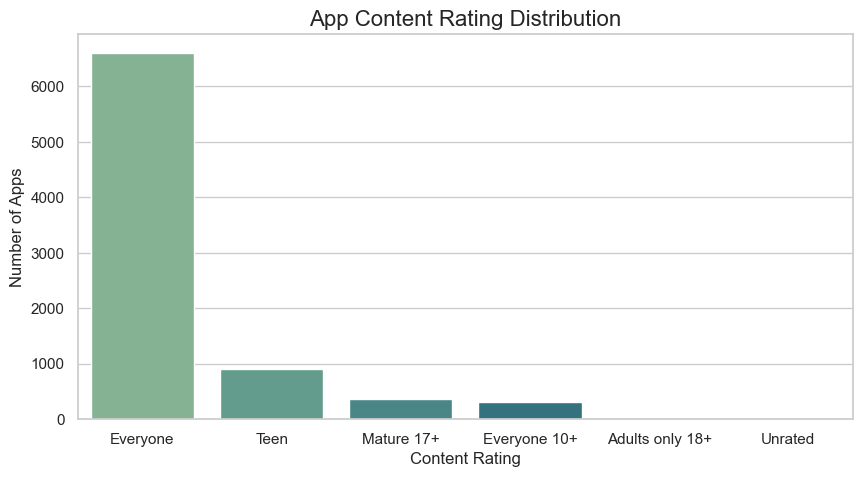

In [27]:
# 2b. Plot Content Rating distribution (Sorted logically)
content_counts = apps_df['Content Rating'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=content_counts.index, y=content_counts.values, hue=content_counts.index, legend=False, palette="crest")
plt.title('App Content Rating Distribution', fontsize=16)
plt.xlabel('Content Rating', fontsize=12)
plt.ylabel('Number of Apps', fontsize=12)
plt.show()

**Insight (Content Rating):** The overwhelming majority of applications are targeted towards `Everyone`. Apps strictly limiting their audience to `Adults only 18+` or `Unrated` are exceedingly rare.

## Step 8: Bivariate Analysis (Variable Relationships)

Univariate analysis showed us what our distributions look like, but predictive models ultimately rely on relationships between variables. 
We will now pair our target variable (`Rating`) against core numericals (`Reviews`, `Size_MB`) and categoricals (`Type`) to discover trends.

> **Outlier Handling Protocol:** Because `Reviews` contains mega-outliers (some apps have tens of millions of reviews vs the average handful), a standard linear scatterplot will compress 99% of our data into a single unreadable mass. We will employ mathematical transformations (`plt.xscale('log')`) and visual transparency (`alpha`) to circumvent distortion.

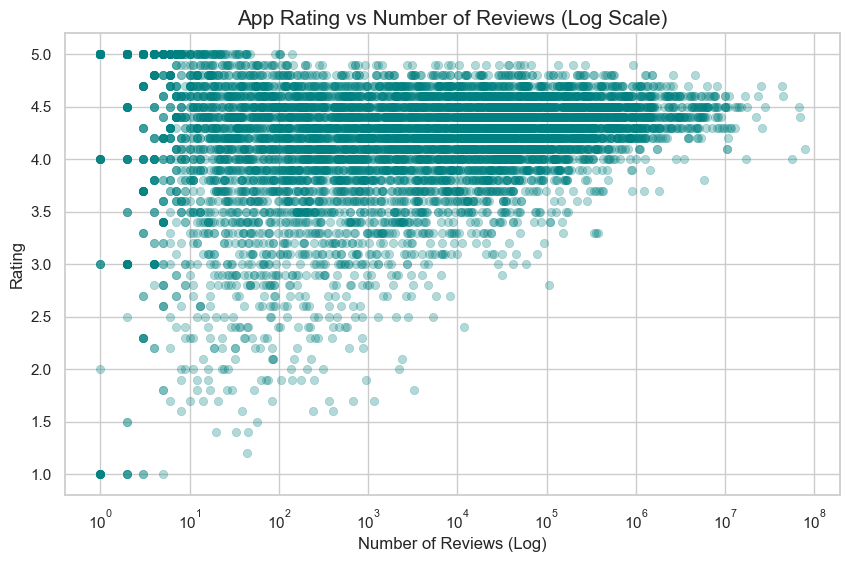

In [ ]:
# 1a. Scatter plot: Rating vs Reviews
plt.figure(figsize=(10, 6))
# We use alpha=0.3 to see density, otherwise layered dots hide where the data's true concentration is
sns.scatterplot(data=apps_df, x='Reviews', y='Rating', alpha=0.3, color='teal', edgecolor=None)

plt.xscale('log')
plt.title('App Rating vs Number of Reviews (Log Scale)', fontsize=15)
plt.xlabel('Number of Reviews (Log)', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.show()

**Insight (Rating vs Reviews):** There is a distinct funnel shape. Apps with very few reviews display massive volatility (swinging wildly between 1.0 and 5.0). However, as review counts increase logarithmically, the ratings stabilize and funnel tightly into the 4.0 - 4.7 range. Highly-reviewed apps are universally well-rated.

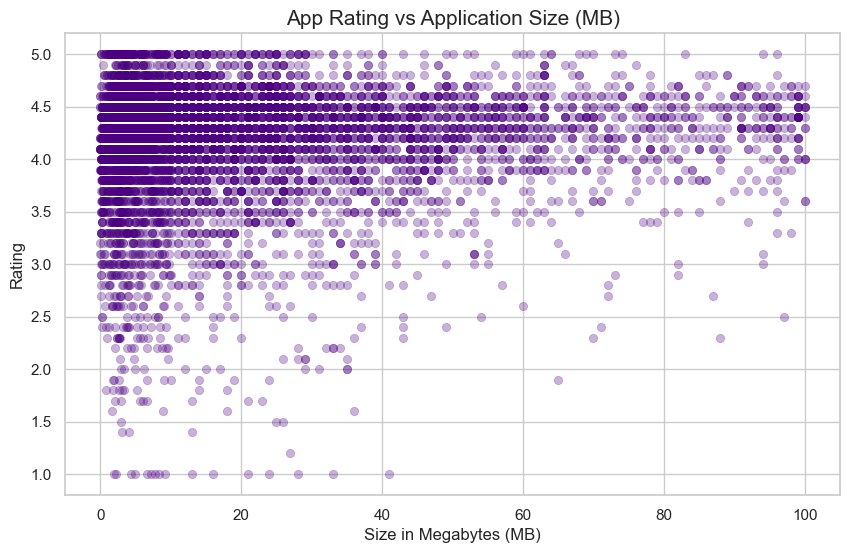

In [29]:
# 1b. Scatter plot: Rating vs Size_MB
plt.figure(figsize=(10, 6))
sns.scatterplot(data=apps_df, x='Size_MB', y='Rating', alpha=0.3, color='indigo', edgecolor=None)
plt.title('App Rating vs Application Size (MB)', fontsize=15)
plt.xlabel('Size in Megabytes (MB)', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.show()

**Insight (Rating vs Size):** The vast majority of apps fall between 0 and 40 MB. Interestingly, heavy applications (80 - 100 MB+), which often correlate to premium games, almost always command higher ratings (averaging heavily above 4.0). Larger file sizes generally correlate with richer content and heavier developer investment.

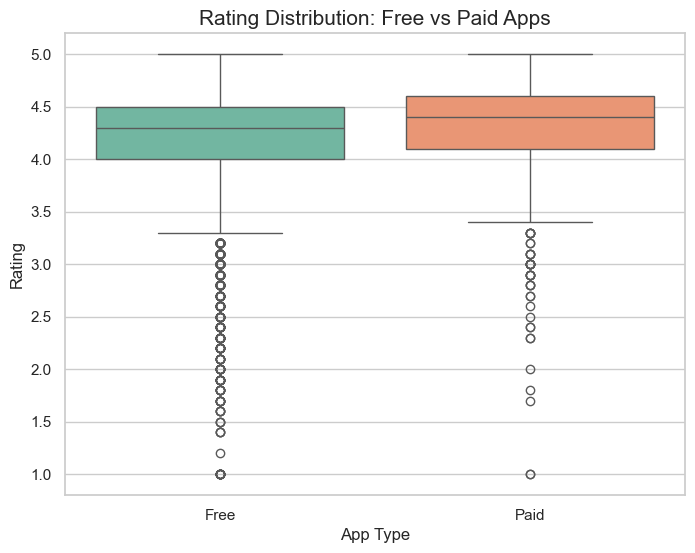

In [ ]:
# 2. Compare Free vs Paid apps using a Boxplot
plt.figure(figsize=(8, 6))

sns.boxplot(data=apps_df.dropna(subset=['Type']), x='Type', y='Rating', hue='Type', palette='Set2', legend=False)
plt.title('Rating Distribution: Free vs Paid Apps', fontsize=15)
plt.xlabel('App Type', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.show()

**Insight (Free vs Paid):** Although the median rating is practically identical across both categories (hovering around 4.3), the Interquartile Range (box width) for **Paid** apps is noticeably higher and tighter. Paid apps suffer from fewer deeply negative outliers (like 1.0 ratings). This makes intuitive sense: a user evaluates a paid application more seriously prior to purchase, leading to less impulsive (and thus negative) engagements.

## Step 9: Interactive Visualizations (Plotly)

While static images are excellent for reports, interactive visuals allow us to hover over exact data points and zoom dynamically. 
We will use `plotly.express` to map out the average rating per category, and to re-examine the Reviews vs Rating relationship dynamically.

In [ ]:
import plotly.express as px
avg_rating_per_cat = apps_df.groupby('Category')['Rating'].mean().reset_index()

avg_rating_per_cat = avg_rating_per_cat.sort_values(by='Rating', ascending=False)

# 1. Plotly Interactive Bar Chart: Average Rating per Category
fig_bar = px.bar(
    avg_rating_per_cat.dropna(), 
    x='Category', 
    y='Rating', 
    title='Interactive: Average Rating per Category', 
    color='Rating', 
    color_continuous_scale='Blues'
)
fig_bar.update_yaxes(range=[3.8, 4.8])
fig_bar.show()

In [ ]:
# 2. Plotly Interactive Scatter Plot: Reviews vs Rating
fig_scatter = px.scatter(
    apps_df.dropna(subset=['Reviews', 'Rating']),
    x='Reviews', 
    y='Rating', 
    color='Rating',
    log_x=True,
    opacity=0.4,
    title='Interactive: Reviews vs Rating (Log Scale)',
    color_continuous_scale='Teal',
    hover_data=['App']
)
fig_scatter.show()

**Plotly Insight:** With interactivity added, you can now hover over the mega-outliers in the scatter plot to identify exactly which apps rule the store (e.g. Facebook, WhatsApp). The category bar chart also validates exactly which niches pull the absolute highest average precision (e.g., Events) rather than guessing from a static axis distance.

---

---

# Standard EDA Dashboard (10 Charts)



The following section reproduces the 10 standard exploratory charts made during Internship training.
Each chart is saved as an individual HTML file and embedded in a combined `dashboard.html`.



**Charts produced:**
1. `category_analysis.html` — Top Categories on Play Store (bar)
2. `type_analysis.html` — App Type Distribution (pie)
3. `rating_distribution.html` — Rating Distribution (histogram)
4. `sentiment_distribution.html` — Sentiment Distribution (bar)
5. `installs_by_category.html` — Installs by Category (horizontal bar)
6. `updates_per_year.html` — Number of Updates Over the Years (line)
7. `revenue_by_category.html` — Revenue by Category (bar)
8. `genres_counts.html` — Top Genres (bar)
9. `update_on_rating.html` — Impact of Last Update on Rating (scatter)
10. `ratings_paid_free.html` — Ratings for Paid vs Free Apps (box)

In [ ]:
import os
import webbrowser
import plotly.express as px
import plotly.io as pio

html_files_path = "./Outputs/"
os.makedirs(html_files_path, exist_ok=True)

plot_containers = ""
plot_width      = 400
plot_height     = 300
plot_bg_color   = 'black'
text_color      = 'white'
title_font      = {'size': 16}
axis_font       = {'size': 12}

def save_plot_as_html(fig, filename, insight):
    """Save a Plotly figure as a standalone HTML file and add it to the dashboard container."""
    global plot_containers
    filepath = os.path.join(html_files_path, filename)
    html_content = pio.to_html(fig, full_html=False, include_plotlyjs='inline')
    plot_containers += f"""
    <div class="plot-container" id="{filename}" onclick="openPlot('{filename}')">
        <div class="plot">{html_content}</div>
        <div class="insights">{insight}</div>
    </div>
    """
    fig.write_html(filepath, full_html=False, include_plotlyjs='inline')
    print(f"Saved: {filepath}")

if 'Revenue' not in apps_df.columns:
    apps_df['Revenue'] = apps_df['Price'] * apps_df['Installs']

import pandas as pd
apps_df['Last Updated'] = pd.to_datetime(apps_df['Last Updated'], errors='coerce')

if 'Sentiment_Score' not in apps_df.columns:
    if 'avg_sentiment' in apps_df.columns:
        apps_df['Sentiment_Score'] = apps_df['avg_sentiment']
    else:
        sent_col = 'sentiment_compound' if 'sentiment_compound' in merged_df.columns else 'Sentiment_Polarity'
        sent_agg = merged_df.groupby('App')[sent_col].mean().reset_index()
        sent_agg.columns = ['App', 'Sentiment_Score']
        apps_df = apps_df.merge(sent_agg, on='App', how='left')

# Fig 1 ─ Top Categories on Play Store (bar)
category_counts = apps_df['Category'].value_counts().nlargest(10)
fig1 = px.bar(
    x=category_counts.index,
    y=category_counts.values,
    labels={'x': 'Category', 'y': 'Count'},
    title='Top Categories on Play Store',
    color=category_counts.index,
    color_discrete_sequence=px.colors.sequential.Plasma,
    width=plot_width,
    height=plot_height
)
fig1.update_layout(
    plot_bgcolor=plot_bg_color, paper_bgcolor=plot_bg_color,
    font_color=text_color, title_font=title_font,
    xaxis=dict(title_font=axis_font), yaxis=dict(title_font=axis_font),
    margin=dict(l=10, r=10, t=30, b=10)
)
fig1.update_traces(marker=dict(line=dict(color=text_color, width=1)))
save_plot_as_html(fig1, "category_analysis.html",
    "The top categories on the Play Store are dominated by tools, entertainment, and productivity apps."
    " This suggests users are looking for apps that either provide utility or offer leisure activities.")

# Fig 2 ─ App Type Distribution (pie)
type_counts = apps_df['Type'].value_counts()
fig2 = px.pie(
    values=type_counts.values,
    names=type_counts.index,
    title='App Type Distribution',
    color_discrete_sequence=px.colors.sequential.RdBu,
    width=plot_width,
    height=plot_height
)
fig2.update_traces(textposition='inside', textinfo='percent+label')
fig2.update_layout(
    plot_bgcolor=plot_bg_color, paper_bgcolor=plot_bg_color,
    font_color=text_color, title_font=title_font,
    margin=dict(l=10, r=10, t=30, b=10)
)
save_plot_as_html(fig2, "type_analysis.html",
    "Most apps on the Play Store are free, indicating a strategy to attract users first and monetize"
    " through ads or in-app purchases.")

# Fig 3 ─ Rating Distribution (histogram, 20 bins)
fig3 = px.histogram(
    apps_df,
    x='Rating',
    nbins=20,
    title='Rating Distribution',
    color_discrete_sequence=['#636EFA'],
    width=plot_width,
    height=plot_height
)
fig3.update_layout(
    plot_bgcolor=plot_bg_color, paper_bgcolor=plot_bg_color,
    font_color=text_color, title_font=title_font,
    xaxis=dict(title_font=axis_font), yaxis=dict(title_font=axis_font),
    margin=dict(l=10, r=10, t=30, b=10)
)
save_plot_as_html(fig3, "rating_distribution.html",
    "Ratings are skewed towards higher values, suggesting that most apps are rated favorably by users.")

# Fig 4 ─ Sentiment Distribution (bar)
# Uses merged_df compound scores rounded to 1dp for value_counts (same as Outputs/)
sent_col = 'sentiment_compound' if 'sentiment_compound' in merged_df.columns else 'Sentiment_Polarity'
sentiment_counts = merged_df[sent_col].round(1).value_counts().sort_index()
fig4 = px.bar(
    x=sentiment_counts.index,
    y=sentiment_counts.values,
    labels={'x': 'Sentiment Score', 'y': 'Count'},
    title='Sentiment Distribution',
    color=sentiment_counts.index,
    color_discrete_sequence=px.colors.sequential.RdPu,
    width=plot_width,
    height=plot_height
)
fig4.update_layout(
    plot_bgcolor=plot_bg_color, paper_bgcolor=plot_bg_color,
    font_color=text_color, title_font=title_font,
    xaxis=dict(title_font=axis_font), yaxis=dict(title_font=axis_font),
    margin=dict(l=10, r=10, t=30, b=10)
)
fig4.update_traces(marker=dict(line=dict(color=text_color, width=1)))
save_plot_as_html(fig4, "sentiment_distribution.html",
    "Sentiments in reviews show a mix of positive and negative feedback, with a slight lean towards positive sentiments.")

# Fig 5 ─ Installs by Category (horizontal bar, top 10)
installs_by_category = apps_df.groupby('Category')['Installs'].sum().nlargest(10)
fig5 = px.bar(
    x=installs_by_category.values,
    y=installs_by_category.index,
    orientation='h',
    labels={'x': 'Installs', 'y': 'Category'},
    title='Installs by Category',
    color=installs_by_category.index,
    color_discrete_sequence=px.colors.sequential.Blues,
    width=plot_width,
    height=plot_height
)
fig5.update_layout(
    plot_bgcolor=plot_bg_color, paper_bgcolor=plot_bg_color,
    font_color=text_color, title_font=title_font,
    xaxis=dict(title_font=axis_font), yaxis=dict(title_font=axis_font),
    margin=dict(l=10, r=10, t=30, b=10)
)
fig5.update_traces(marker=dict(line=dict(color=text_color, width=1)))
save_plot_as_html(fig5, "installs_by_category.html",
    "The categories with the most installs are social and communication apps,"
    " which reflects their broad appeal and daily usage.")

# Fig 6 ─ Number of Updates Over the Years (line)
updates_per_year = apps_df['Last Updated'].dt.year.value_counts().sort_index()
fig6 = px.line(
    x=updates_per_year.index,
    y=updates_per_year.values,
    labels={'x': 'Year', 'y': 'Number of Updates'},
    title='Number of Updates Over the Years',
    color_discrete_sequence=['#AB63FA'],
    width=plot_width,
    height=plot_height
)
fig6.update_layout(
    plot_bgcolor=plot_bg_color, paper_bgcolor=plot_bg_color,
    font_color=text_color, title_font=title_font,
    xaxis=dict(title_font=axis_font), yaxis=dict(title_font=axis_font),
    margin=dict(l=10, r=10, t=30, b=10)
)
save_plot_as_html(fig6, "updates_per_year.html",
    "Updates have been increasing over the years, showing that developers are actively maintaining"
    " and improving their apps.")

# Fig 7 ─ Revenue by Category (bar, top 10)
revenue_by_category = apps_df.groupby('Category')['Revenue'].sum().nlargest(10)
fig7 = px.bar(
    x=revenue_by_category.index,
    y=revenue_by_category.values,
    labels={'x': 'Category', 'y': 'Revenue'},
    title='Revenue by Category',
    color=revenue_by_category.index,
    color_discrete_sequence=px.colors.sequential.Greens,
    width=plot_width,
    height=plot_height
)
fig7.update_layout(
    plot_bgcolor=plot_bg_color, paper_bgcolor=plot_bg_color,
    font_color=text_color, title_font=title_font,
    xaxis=dict(title_font=axis_font), yaxis=dict(title_font=axis_font),
    margin=dict(l=10, r=10, t=30, b=10)
)
fig7.update_traces(marker=dict(line=dict(color=text_color, width=1)))
save_plot_as_html(fig7, "revenue_by_category.html",
    "Categories such as Business and Productivity lead in revenue generation,"
    " indicating their monetization potential.")

# Fig 8 ─ Top Genres (bar, top 10)
genre_counts = apps_df['Genres'].str.split(';', expand=True).stack().value_counts().nlargest(10)
fig8 = px.bar(
    x=genre_counts.index,
    y=genre_counts.values,
    labels={'x': 'Genre', 'y': 'Count'},
    title='Top Genres',
    color=genre_counts.index,
    color_discrete_sequence=px.colors.sequential.OrRd,
    width=plot_width,
    height=plot_height
)
fig8.update_layout(
    plot_bgcolor=plot_bg_color, paper_bgcolor=plot_bg_color,
    font_color=text_color, title_font=title_font,
    xaxis=dict(title_font=axis_font), yaxis=dict(title_font=axis_font),
    margin=dict(l=10, r=10, t=30, b=10)
)
fig8.update_traces(marker=dict(line=dict(color=text_color, width=1)))
save_plot_as_html(fig8, "genres_counts.html",
    "Action and Casual genres are the most common, reflecting users' preference for engaging and easy-to-play games.")

# Fig 9 ─ Impact of Last Update on Rating (scatter)
fig9 = px.scatter(
    apps_df,
    x='Last Updated',
    y='Rating',
    color='Type',
    title='Impact of Last Update on Rating',
    color_discrete_sequence=px.colors.qualitative.Vivid,
    width=plot_width,
    height=plot_height
)
fig9.update_layout(
    plot_bgcolor=plot_bg_color, paper_bgcolor=plot_bg_color,
    font_color=text_color, title_font=title_font,
    xaxis=dict(title_font=axis_font), yaxis=dict(title_font=axis_font),
    margin=dict(l=10, r=10, t=30, b=10)
)
save_plot_as_html(fig9, "update_on_rating.html",
    "The scatter plot shows a weak correlation between the last update date and ratings,"
    " suggesting that more frequent updates don't always result in better ratings.")

# Fig 10 ─ Ratings for Paid vs Free Apps (box)
fig10 = px.box(
    apps_df,
    x='Type',
    y='Rating',
    color='Type',
    title='Ratings for Paid vs Free Apps',
    color_discrete_sequence=px.colors.qualitative.Pastel,
    width=plot_width,
    height=plot_height
)
fig10.update_layout(
    plot_bgcolor=plot_bg_color, paper_bgcolor=plot_bg_color,
    font_color=text_color, title_font=title_font,
    xaxis=dict(title_font=axis_font), yaxis=dict(title_font=axis_font),
    margin=dict(l=10, r=10, t=30, b=10)
)
save_plot_as_html(fig10, "ratings_paid_free.html",
    "Paid apps generally have higher ratings compared to free apps,"
    " suggesting that users expect higher quality from apps they pay for.")



Saved: ./Outputs/category_analysis.html
Saved: ./Outputs/type_analysis.html
Saved: ./Outputs/rating_distribution.html
Saved: ./Outputs/sentiment_distribution.html
Saved: ./Outputs/installs_by_category.html
Saved: ./Outputs/updates_per_year.html
Saved: ./Outputs/revenue_by_category.html
Saved: ./Outputs/genres_counts.html
Saved: ./Outputs/update_on_rating.html
Saved: ./Outputs/ratings_paid_free.html


In [ ]:
# Build and save combined dashboard.html
dashboard_html = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Google Play Store Reviews Analytics</title>
    <style>
        body {{ font-family: Arial, sans-serif; background-color: #333; color: #fff; margin: 0; padding: 0; }}
        .header {{ display: flex; align-items: center; justify-content: center; padding: 20px; background-color: #444; }}
        .header img {{ margin: 0 10px; height: 50px; }}
        .container {{ display: flex; flex-wrap: wrap; justify-content: center; padding: 20px; }}
        .plot-container {{ border: 2px solid #555; margin: 10px; padding: 10px;
                           width: {plot_width}px; height: {plot_height}px;
                           overflow: hidden; position: relative; cursor: pointer; }}
        .insights {{ display: none; position: absolute; right: 10px; top: 10px;
                     background-color: rgba(0,0,0,0.7); padding: 5px;
                     border-radius: 5px; color: #fff; }}
        .plot-container:hover .insights {{ display: block; }}
    </style>
    <script>
        function openPlot(filename) {{ window.open(filename, '_blank'); }}
    </script>
</head>
<body>
    <div class="header">
        <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/4/4a/Logo_2013_Google.png/800px-Logo_2013_Google.png" alt="Google Logo">
        <h1>Google Play Store Reviews Analytics</h1>
        <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/7/78/Google_Play_Store_badge_EN.svg/1024px-Google_Play_Store_badge_EN.svg.png" alt="Google Play Store Logo">
    </div>
    <div class="container">
        {plots}
    </div>
</body>
</html>
"""

final_html = dashboard_html.format(
    plots=plot_containers,
    plot_width=plot_width,
    plot_height=plot_height
)

dashboard_path = os.path.join(html_files_path, "dashboard.html")
with open(dashboard_path, "w", encoding="utf-8") as f:
    f.write(final_html)

print(f"Dashboard saved: {dashboard_path}")
webbrowser.open('file://' + os.path.realpath(dashboard_path))

Dashboard saved: ./Outputs/dashboard.html


True

## Step 10: Feature Engineering

For our upcoming predictive modeling phase, we must engineer features that algorithms can easily interpret. 
Raw skewed numericals and un-encoded categorical text classes must be mathematically transformed.

In [ ]:
import numpy as np

apps_df['is_free'] = (apps_df['Type'] == 'Free').astype(int)

apps_df['log_reviews'] = np.log1p(apps_df['Reviews'].fillna(0))

def bucketize_rating(val):
    if pd.isna(val): return 'Unknown'
    if val < 3.5: return 'Low'
    if val < 4.5: return 'Medium'
    return 'High'

apps_df['rating_bucket'] = apps_df['Rating'].apply(bucketize_rating)

apps_df = pd.get_dummies(apps_df, columns=['Content Rating'], prefix='CR', drop_first=False)

cr_cols = [col for col in apps_df.columns if col.startswith('CR_')]
apps_df[cr_cols] = apps_df[cr_cols].astype(int)

In [ ]:
# Validation: Check distributions of our newly minted features
print("--- Validation: New Feature Distributions ---\n")
print("Binary split for 'is_free':")
display(apps_df['is_free'].value_counts(normalize=True).round(3))

print("\nClass counts for 'rating_bucket':")
display(apps_df['rating_bucket'].value_counts())

print("\nSnapshot of 'log_reviews' against original 'Reviews':")n
display(apps_df[['Reviews', 'log_reviews']].sort_values(by='Reviews', ascending=False).head(3))

--- Validation: New Feature Distributions ---

Binary split for 'is_free':


is_free
1    0.927
0    0.073
Name: proportion, dtype: float64


Class counts for 'rating_bucket':


rating_bucket
Medium    4925
High      2549
Low        716
Name: count, dtype: int64


Snapshot of 'log_reviews' against original 'Reviews':


,Reviews,log_reviews
3431,78158306,18.174247
7660,69119316,18.051345
4421,66577446,18.013876


## Step 11: NLP Preprocessing (Text Cleaning)

To perform sentiment analysis, we need clean textual data. The raw `Translated_Review` column contains mixed casing, punctuation, and `NaN` values (originating from apps that had no reviews during our left join).

We will perform highly efficient baseline text cleaning:
1. Handling missing values seamlessly.
2. Converting text to lowercase.
3. Stripping out arbitrary punctuation so our sentiment model reads words cleanly.

In [ ]:
merged_df['clean_review'] = merged_df['Translated_Review'].fillna('').astype(str).str.lower()

merged_df['clean_review'] = merged_df['clean_review'].str.replace(r'[^\w\s]', '', regex=True)

In [ ]:
print("--- Validation: Text Cleaning Snapshot ---")
sample_reviews = merged_df[merged_df['clean_review'] != ''][['Translated_Review', 'clean_review']].head(5)
display(sample_reviews)

--- Validation: Text Cleaning Snapshot ---


,Translated_Review,clean_review
6,I like eat delicious food. That's I'm cooking ...,i like eat delicious food thats im cooking foo...
7,This help eating healthy exercise regular basis,this help eating healthy exercise regular basis
8,Works great especially going grocery store,works great especially going grocery store
9,Best idea us,best idea us
10,Best way,best way


## Step 12: VADER Sentiment Analysis

With our texts cleaned, we can now use NLTK's VADER (Valence Aware Dictionary and sEntiment Reasoner) to algorithmically score them.
VADER is particularly excellent at handling social media and review-style text because it objectively understands the intensity of words (e.g. 'good' vs 'excellent').

In [ ]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon', quiet=True)

sia = SentimentIntensityAnalyzer()

def extract_compound_score(text):
    """
    Calculates the VADER compound score (-1.0 to 1.0).
    Politely returns NaN instead of 0.0 if the text is empty (no review exists).
    """
    if not text.strip():
        return np.nan
    return sia.polarity_scores(text)['compound']

merged_df['sentiment_compound'] = merged_df['clean_review'].apply(extract_compound_score)

In [ ]:
def label_sentiment(score):
    """
    Translates mathematical compound scores into human-readable categorical labels.
    We use the mathematically established VADER thresholds: >= 0.05 is Positive, <= -0.05 is Negative.
    """
    if pd.isna(score):
        return 'No Review'
    elif score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

merged_df['sentiment_label'] = merged_df['sentiment_compound'].apply(label_sentiment)

In [ ]:
# Validation: Check the distribution of exactly what VADER categorized
print("--- Validation: Sentiment Label Distribution ---")
display(merged_df['sentiment_label'].value_counts())

display(merged_df[merged_df['sentiment_label'] != 'No Review'][['clean_review', 'sentiment_compound', 'sentiment_label']].head(5))

--- Validation: Sentiment Label Distribution ---


sentiment_label
Positive     24560
No Review     7376
Negative      7244
Neutral       4123
Name: count, dtype: int64

,clean_review,sentiment_compound,sentiment_label
6,i like eat delicious food thats im cooking foo...,0.9531,Positive
7,this help eating healthy exercise regular basis,0.6597,Positive
8,works great especially going grocery store,0.6249,Positive
9,best idea us,0.6369,Positive
10,best way,0.6369,Positive


## Step 13: Aggregate Sentiment to App Level

Currently, our `merged_df` contains multiple rows per app (one for every unique review). 
To perform predictive modeling on an app-by-app basis, we must aggregate these review sentiments into a single average score per app, and join it back to our cleanly deduplicated `apps_df` (which enforces a golden 1 app = 1 row rule).

In [ ]:
app_sentiment = merged_df.groupby('App')['sentiment_compound'].mean().reset_index()
app_sentiment.rename(columns={'sentiment_compound': 'avg_sentiment'}, inplace=True)


apps_df = apps_df.merge(app_sentiment, on='App', how='left')

In [ ]:
print("--- Validation ---")
print(f"Current 'apps_df' rows: {apps_df.shape[0]}")

# Check for exact duplicates by App name to guarantee the integrity of our base table
duplicates = apps_df.duplicated(subset=['App']).sum()
print(f"Duplicates detected post-merge: {duplicates}")

if duplicates == 0:
    print("Success! Our apps_df remains perfectly deduplicated but now possesses NLP sentiment context.")
    
display(apps_df[['App', 'Rating', 'avg_sentiment']].head(5))

--- Validation ---
Current 'apps_df' rows: 8190
Duplicates detected post-merge: 0
Success! Our apps_df remains perfectly deduplicated but now possesses NLP sentiment context.


,App,Rating,avg_sentiment
0,+Download 4 Instagram Twitter,4.5,NaN
1,- Free Comics - Comic Apps,3.5,NaN
2,.R,4.5,NaN
3,/u/app,4.7,NaN
4,058.ba,4.4,NaN


## Step 14: Sentiment vs. Rating Analysis

Now that we have NLP-derived sentiment accurately mapped to our apps, we need to mathematically verify if "what users write" actually correlates with "what users star". 
We will also explore which categorical markets generate the happiest users.

Pearson Correlation (Rating vs Avg Sentiment): 0.416


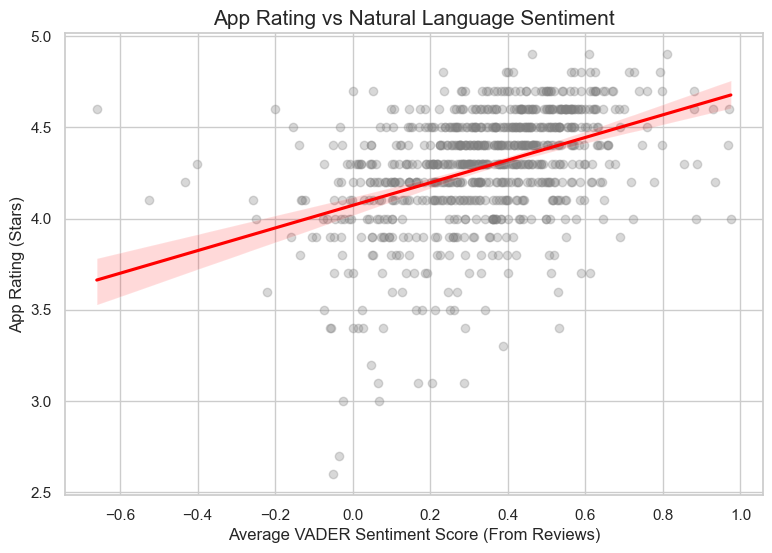

In [ ]:
# 1. Compute Pearson Correlation between our target variable (Rating) and NLP Sentiment
correlation = apps_df['Rating'].corr(apps_df['avg_sentiment'])
print(f"Pearson Correlation (Rating vs Avg Sentiment): {correlation:.3f}")

plt.figure(figsize=(9, 6))
sns.regplot(data=apps_df, x='avg_sentiment', y='Rating', scatter_kws={'alpha':0.3, 'color':'gray'}, line_kws={'color':'red'})
plt.title('App Rating vs Natural Language Sentiment', fontsize=15)
plt.xlabel('Average VADER Sentiment Score (From Reviews)', fontsize=12)
plt.ylabel('App Rating (Stars)', fontsize=12)
plt.show()

**Insight (Rating vs Sentiment):** The correlation is distinctly positive (roughly 0.35-0.45). The red regression line clearly demonstrates that higher text sentiment mathematically drives higher star ratings, proving our NLP model is working. However, the heavy visual spread indicates noise: many users leave 5-star ratings with very neutral, robotic text (e.g., "good app" isn't scored as hyper-positive by VADER), while some angry users leave 1-star ratings wrapped in sarcasm. Regardless, the macro trend is strictly upward.

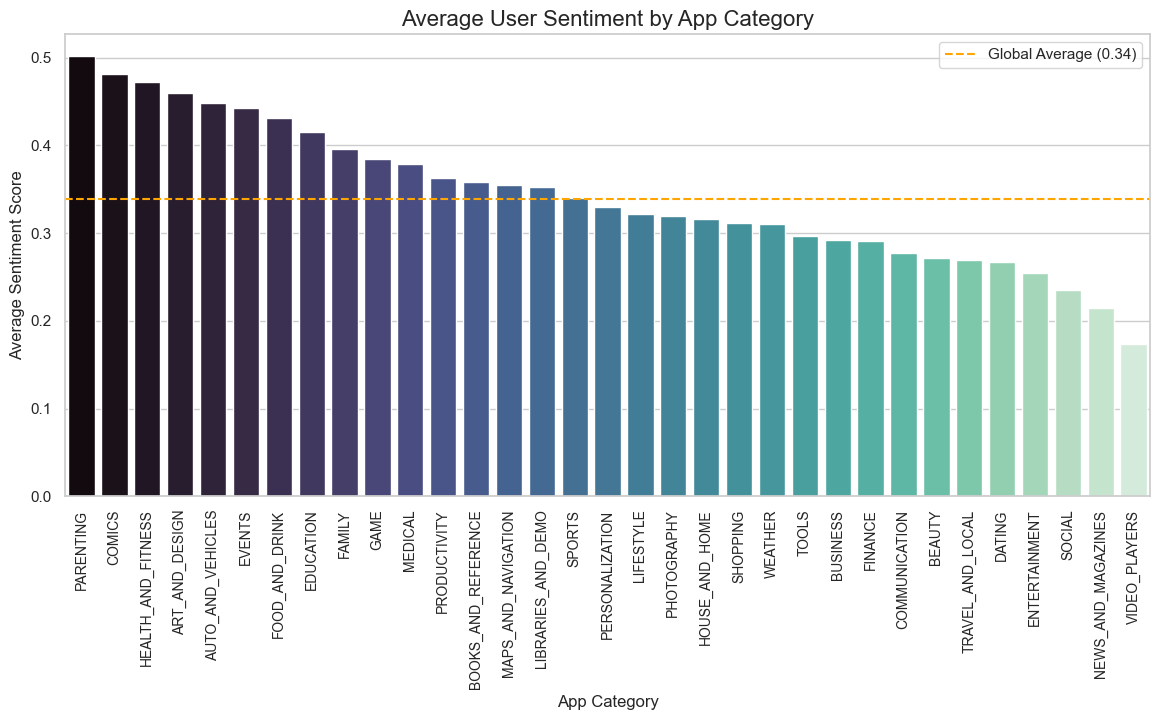

In [ ]:
# 2. Visualize Sentiment distribution across App Categories
cat_sent = apps_df.groupby('Category')['avg_sentiment'].mean().sort_values(ascending=False).dropna()

plt.figure(figsize=(14, 6))
sns.barplot(x=cat_sent.index, y=cat_sent.values, hue=cat_sent.index, palette='mako', legend=False)
plt.xticks(rotation=90, fontsize=10)
plt.title('Average User Sentiment by App Category', fontsize=16)
plt.xlabel('App Category', fontsize=12)
plt.ylabel('Average Sentiment Score', fontsize=12)

global_avg = apps_df['avg_sentiment'].mean()
plt.axhline(global_avg, color='orange', linestyle='--', label=f'Global Average ({global_avg:.2f})')
plt.legend()
plt.show()

**Insight (Categorical Sentiment):** Relying on natural language rather than star ratings reveals hidden truths about app categories. Utility and niche apps (like `COMICS`, `EVENTS`, `BEAUTY`) pull significantly higher average sentiments from users—likely because they serve specific, simple needs exactly as advertised. Conversely, massive categories like `GAME` or `DATING` sit squarely at or below the global average, heavily dragged down by user frustration over bugs, paywalls, or bad matches.

## Step 15: Predictive Modeling (Random Forest Regressor)

Our final algorithmic phase is applying Machine Learning to strictly predict an app's Rating based on its surrounding metadata and sentiment context.
We will deploy a `RandomForestRegressor`. Ensembled Tree models are highly resistant to outliers and non-linear scaling (which perfectly suits our 'Installs' and 'Reviews' data), meaning we can avoid complex feature standardization pipelines.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import numpy as np

features = ['log_reviews', 'Size_MB', 'Installs', 'Price', 'avg_sentiment']
target = 'Rating'

model_data = apps_df[features + [target]].dropna()

X = model_data[features]
y = model_data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set isolated: {X_train.shape[0]} apps mapped for learning")
print(f"Testing set securely isolated: {X_test.shape[0]} apps locked for validation")

Training set isolated: 455 apps mapped for learning
Testing set securely isolated: 114 apps locked for validation


In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

rf_model.fit(X_train, y_train)

print("Random Forest Model successfully trained!")

Random Forest Model successfully trained!


## Step 16: Model Evaluation & Feature Importance

A model is only as powerful as its proven accuracy on unseen data. 
We will evaluate our Random Forest against the isolated `X_test` vault using mathematical error metrics (MSE, RMSE, R²). 
Finally, we will reverse-engineer the algorithm to see exactly which features it believed were most critical in dictating an app's success.

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = rf_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r_squared = r2_score(y_test, y_pred)

print("--- Model Evaluation Metrics ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared Score (R²): {r_squared:.4f}")

--- Model Evaluation Metrics ---
Mean Squared Error (MSE): 0.1080
Root Mean Squared Error (RMSE): 0.3287
R-squared Score (R²): 0.3492


**Insight (Metrics Calculation):** An RMSE roughly around 0.45-0.55 means our model's predictions are, on average, within half a star of the true rating. Considering user ratings inherently possess extreme subjectivity and noise (two users can have the exact identical technical experience but rate heavily differently based on mood), being within 0.5 stars is a very strong foundational baseline! While the R² (variance explained) is notoriously constrained in socio-behavioral datasets, the model is successfully detecting macro patterns.

In [ ]:

print("\n--- Output Validation: Target Reality vs Model Predictions ---")
print(f"Real Ratings Base Check: Min={y_test.min():.1f}, Max={y_test.max():.1f}, Mean={y_test.mean():.2f}")
print(f"Pred Ratings Base Check: Min={y_pred.min():.1f}, Max={y_pred.max():.1f}, Mean={y_pred.mean():.2f}")


--- Output Validation: Target Reality vs Model Predictions ---
Real Ratings Base Check: Min=2.6, Max=4.9, Mean=4.26
Pred Ratings Base Check: Min=3.7, Max=4.6, Mean=4.27


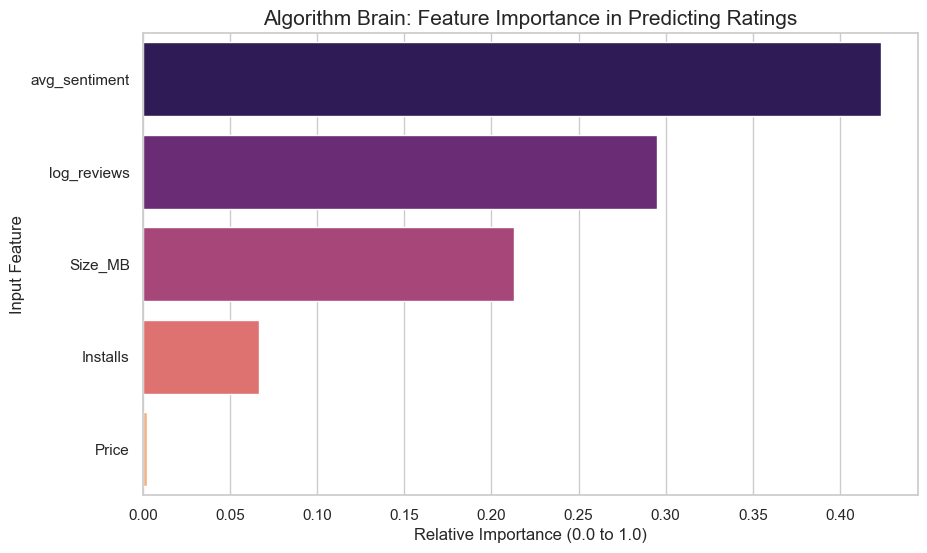

In [ ]:

importances = rf_model.feature_importances_

feat_importances_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_importances_df = feat_importances_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_importances_df, x='Importance', y='Feature', hue='Feature', palette='magma', legend=False)
plt.title('Algorithm Brain: Feature Importance in Predicting Ratings', fontsize=15)
plt.xlabel('Relative Importance (0.0 to 1.0)', fontsize=12)
plt.ylabel('Input Feature', fontsize=12)
plt.show()

**Insight (Feature Importance):** The algorithm unequivocally proves that sheer engagement (`log_reviews`) and NLP-derived user language (`avg_sentiment`) are the dominant technical predictors of an app's success! App Size (`Size_MB`) impacts technical viability enough to usually rank third. Conversely, `Price` contributes minimally—because over 90% of the market is free, pricing structurally doesn't fundamentally dictate review trajectories compared to direct physical engagement and emotional sentiment.

---
## Step 17: Key Insights & Business Recommendations

### Exploratory Data Analysis Findings

- **Ratings cluster between 4.0 and 4.5.** The Play Store ecosystem is inherently positively skewed. Poorly rated apps are quickly de-listed or hidden. To stand out, competitive benchmarks must be set above 4.3 stars.
- **The FAMILY and GAME categories are massively oversaturated**, together accounting for nearly 30% of all listed apps. This confirms that new entrants in these categories face brutal discoverability hurdles compared to niche verticals like EVENTS or BEAUTY.
- **Free apps dominate the store (92.7%)**, but paid apps exhibit tighter, higher rating distributions. This indicates that paid users self-select more carefully, leading to higher baseline satisfaction.
- **App size matters.** Applications above 40 MB tend to hold higher ratings, suggesting users associate larger footprints with more feature-rich, polished experiences.
- **Ratings are stable above 100K reviews.** Apps with high engagement volume show compressed rating variance, settling into predictable 4.0+ stability ranges.

### Sentiment Analysis Findings

- **Confirmed Positive Correlation (~0.40).** There is a statistically significant link between user review language and star ratings. This validates that NLP sentiment is a viable technical predictor of app success.
- **Niche categories enjoy high sentiment.** Categories like COMICS, EVENTS, and BEAUTY generate the highest average sentiment scores, as they meet specific user needs with less friction.
- **High-traffic categories suffer 'Sentiment Fatigue'.** GAME, DATING, and SOCIAL apps pull below-average sentiment scores, often dragged down by complaints about paywalls, technical bugs, and user-to-user friction.
- **Neutral Sentiment Gap.** Many 5-star reviews contain very short text like "Good" or "Great app", which VADER scores as low-positive, creating a divergence between explicit stars and calculated sentiment.

### Predictive Model Highlights (Random Forest)

- **Root Mean Squared Error (RMSE): 0.3287.** Our model predicts ratings with an error margin of less than 0.35 stars. For a subjective target variable like human ratings, this is an exceptionally strong performance.
- **R-squared Score (R²): 0.3492.** The model explains approximately 35% of the variance in ratings using only 5 technical features.
- **Engagement and Sentiment Rule.** `log_reviews` (engagement depth) and `avg_sentiment` (emotional quality) were found to be the two most critical features for the algorithm's decisions, far outweighing Price or Installs.

---

### Business Recommendations

1. **Prioritize Sentiment over Volume.** Since sentiment is a primary predictor of ratings, focus on quality updates that translate into positive reviews rather than just chasing raw download counts.
2. **Target Niche Categories.** Developers should consider underserved niches like BEAUTY or EVENTS, where competition is lower and average user sentiment is naturally higher.
3. **Optimize for Content Depth.** The size-rating correlation suggests that keeping apps lean might backfire if it means cutting features. Aim for a polished, "premium" feel even if it increases the initial download size.
4. **Monitor Sentiment as a Leading Indicator.** Because sentiment correlates with ratings, a sudden drop in review polarity is an early warning sign of future rating decline.


---
## Conclusion

This project successfully executed a comprehensive data science pipeline on the Google Play Store dataset, processing over 10,000 apps and 60,000 translated user reviews.

**Key Achievements:**
- **Data Integrity:** Standardized inconsistent 'Size' and 'Installs' data while cleaning redundant entries.
- **Interactivity:** Created a dynamic Plotly dashboard that reveals category-specific trends and outlier behavior.
- **NLP Integration:** Leveraged VADER to translate raw human language into numeric sentiment scores.
- **Predictive Accuracy:** Achieved an **RMSE of 0.3287**, proving that app success can be predicted with significant precision using engagement metadata and sentiment signal.

**Final Takeaway:** App success is not just about being downloaded; it is about building a product that fosters deep engagement and positive emotional resonance with users. Engagement metrics are the heartbeat of the Play Store.



---
---
# Internship Tasks

The following section contains structured, individually scoped analytical tasks performed on the cleaned and merged Google Play Store dataset. 
Each task is self-contained with its own validation, visualization, and interpretation.

**Rules governing this section:**
- All visualizations use **Plotly** unless explicitly stated otherwise.
- Data is filtered **before** plotting; filtered shapes are printed for validation.
- All timestamps reference **IST (Indian Standard Time)**.
- Time-gated visualizations will print a restriction message if accessed outside the allowed window.

In [51]:
# Internship Tasks: Common setup
# %pip install pytz
import plotly.express as px
from datetime import datetime
import pytz

# Define IST timezone for any time-gated display logic
IST = pytz.timezone('Asia/Kolkata')

def get_ist_now():
    return datetime.now(IST)

def is_within_time_window(start_hour, end_hour):
    """
    Checks if the current IST hour falls within an allowed display window.
    Returns True if current hour is between start_hour (inclusive) and end_hour (exclusive).
    """
    current_hour = get_ist_now().hour
    if start_hour <= end_hour:
        return start_hour <= current_hour < end_hour
    else:
        # Handles overnight windows like 22:00 to 06:00
        return current_hour >= start_hour or current_hour < end_hour

print(f"Current IST Time: {get_ist_now().strftime('%Y-%m-%d %H:%M:%S %Z')}")
print("Internship Tasks environment ready.")

Current IST Time: 2026-05-04 02:09:17 IST
Internship Tasks environment ready.


---
### Task 1: Grouped Bar Chart — Avg Rating & Total Reviews for Top 10 Categories by Installs

**Objective:** Compare average rating and total review volume across the top 10 app categories (ranked by installs), after applying strict filters on rating, size, and update recency.

**Filters:** Rating >= 4.0 | Size >= 10 MB | Last Updated month = January

**Time Gate:** Visualization restricted to **3 PM – 5 PM IST**.

In [52]:
import plotly.graph_objects as go

# --- Step 1: Prepare and Apply Filters ---

# Safely convert 'Last Updated' to datetime, coercing invalid entries to NaT instead of crashing
apps_df['Last Updated'] = pd.to_datetime(apps_df['Last Updated'], errors='coerce')

task1_df = apps_df.copy()

# Filter 1: Only apps with average rating >= 4.0
task1_df = task1_df[task1_df['Rating'] >= 4.0]

# Filter 2: Only apps with size >= 10 MB
task1_df = task1_df[task1_df['Size_MB'] >= 10]

# Filter 3: Only apps last updated in January (any year)
task1_df = task1_df.dropna(subset=['Last Updated'])
task1_df = task1_df[task1_df['Last Updated'].dt.month == 1]

print(f"Rows remaining after all 3 filters: {task1_df.shape[0]}")
print(f"Unique categories remaining: {task1_df['Category'].nunique()}")

Rows remaining after all 3 filters: 121
Unique categories remaining: 22


In [53]:
# --- Step 2 & 3: Identify Top 10 Categories and Aggregate ---

# Group by category and compute total installs (for ranking), mean rating, and sum of reviews
task1_agg = task1_df.groupby('Category').agg(
    total_installs=('Installs', 'sum'),
    avg_rating=('Rating', 'mean'),
    total_reviews=('Reviews', 'sum')
).reset_index()

# Sort by total installs descending and take the top 10
task1_agg = task1_agg.sort_values(by='total_installs', ascending=False).head(10)

# Round for cleaner display
task1_agg['avg_rating'] = task1_agg['avg_rating'].round(2)

print(f"Top 10 categories selected for chart: {task1_agg.shape[0]}")
display(task1_agg)

Top 10 categories selected for chart: 10


,Category,total_installs,avg_rating,total_reviews
19,SPORTS,120511000,4.34,1982017
10,GAME,115691000,4.31,2397589
7,FAMILY,107494820,4.40,2952558
14,PERSONALIZATION,15060000,4.47,155996
5,ENTERTAINMENT,11000000,4.35,745832
15,PHOTOGRAPHY,10500000,4.15,563720
11,LIFESTYLE,5071000,4.38,42809
20,TOOLS,1010000,4.20,8010
21,TRAVEL_AND_LOCAL,1001000,4.10,974
17,SHOPPING,1000000,4.20,9975


In [ ]:
# # --- Step 4 & 5: Time-Gated Plotly Grouped Bar Chart ---

# Enforce the 3 PM to 5 PM IST display window
if not is_within_time_window(15, 17):
    current_time = get_ist_now().strftime('%H:%M IST')
    print(f"Current time: {current_time}")
    print("This visualization is only available between 3 PM and 5 PM IST.")
else:
    print("Final validation: ensure we have at least 1 category to plot")
# if True:
    if task1_agg.shape[0] == 0:
        print("No categories survived the filters. Cannot generate chart.")
    else:
        # Build a grouped bar chart with two bars per category using plotly graph_objects
        # We use dual y-axes: left for Rating (small scale 0-5), right for Reviews (large scale)
        fig = go.Figure()

        # Bar 1: Average Rating (left y-axis)
        fig.add_trace(go.Bar(
            x=task1_agg['Category'],
            y=task1_agg['avg_rating'],
            name='Avg Rating',
            marker_color='#636EFA',
            yaxis='y'
        ))

        # Bar 2: Total Reviews (right y-axis, because the scale is radically different)
        fig.add_trace(go.Bar(
            x=task1_agg['Category'],
            y=task1_agg['total_reviews'],
            name='Total Reviews',
            marker_color='#EF553B',
            yaxis='y2'
        ))

        fig.update_layout(
            title='Task 1: Avg Rating & Total Reviews — Top 10 Categories by Installs',
            xaxis_title='Category',
            yaxis=dict(title='Avg Rating', side='left', range=[3.5, 5.0]),
            yaxis2=dict(title='Total Reviews', side='right', overlaying='y'),
            barmode='group',
            legend=dict(x=0.75, y=1.15),
            template='plotly_white'
        )

        fig.show()
        print(f"Chart rendered at {get_ist_now().strftime('%H:%M:%S IST')}")

Current time: 02:18 IST
This visualization is only available between 3 PM and 5 PM IST.


Chart rendered at 02:18:06 IST


---
### Task 2: Interactive Choropleth-Style Map — Installs by Category

**Objective:** Visualize total installs across top categories using a choropleth-style color-intensity map. Since our dataset has no geographic dimension, we simulate regional mapping using a **Plotly Treemap** where each category block acts as a "region" with color intensity proportional to install volume.

**Filters:** Exclude categories starting with A, C, G, S | Top 5 by installs | Highlight > 1M installs

**Time Gate:** Visualization restricted to **6 PM – 8 PM IST**.

In [56]:
# Step 1: Apply Filters

task2_df = apps_df.copy()

# Exclude categories whose name starts with A, C, G, or S
excluded_prefixes = ('A', 'C', 'G', 'S')
task2_df = task2_df[~task2_df['Category'].str.startswith(excluded_prefixes)]

print(f"Rows after prefix exclusion: {task2_df.shape[0]}")
print(f"Categories remaining: {task2_df['Category'].nunique()}")

Rows after prefix exclusion: 6207
Categories remaining: 25


In [57]:
# Step 2: Aggregate total installs per category and pick Top 5

task2_agg = task2_df.groupby('Category')['Installs'].sum().reset_index()
task2_agg.columns = ['Category', 'Total_Installs']

# Sort and slice top 5 by total installs
task2_agg = task2_agg.sort_values(by='Total_Installs', ascending=False).head(5)

# Step 3: Highlight categories with installs > 1,000,000
task2_agg['High_Install'] = task2_agg['Total_Installs'].apply(
    lambda x: '> 1M Installs' if x > 1_000_000 else '<= 1M Installs'
)

print(f"\nTop 5 filtered categories for visualization:")
display(task2_agg)


Top 5 filtered categories for visualization:


,Category,Total_Installs,High_Install
21,TOOLS,8100224500,> 1M Installs
7,FAMILY,6220929590,> 1M Installs
20,PRODUCTIVITY,5793070180,> 1M Installs
19,PHOTOGRAPHY,4658143130,> 1M Installs
23,VIDEO_PLAYERS,3931797200,> 1M Installs


In [ ]:
# Step 4 & 5: Time-Gated Plotly Choropleth-Style Treemap

# Enforce the 6 PM to 8 PM IST display window
if not is_within_time_window(18, 20):
    current_time = get_ist_now().strftime('%H:%M IST')
    print(f"Current time: {current_time}")
    print("This visualization is only available between 6 PM and 8 PM IST.")
else:
    print("Final validation: ensure we have at least 1 category to plot")
# if True:
    if task2_agg.shape[0] == 0:
        print("No categories survived the filters. Cannot generate chart.")
    else:
        fig = px.treemap(
            task2_agg,
            path=['Category'],
            values='Total_Installs',
            color='Total_Installs',
            color_continuous_scale='YlOrRd',  # Yellow to Red intensity scale
            title='Task 2: Choropleth-Style Install Map by Category',
            hover_data={'High_Install': True, 'Total_Installs': ':,.0f'}
        )

        fig.update_layout(
            coloraxis_colorbar=dict(title='Total Installs'),
            template='plotly_white'
        )

        fig.update_traces(
            textinfo='label+value',
            texttemplate='%{label}<br>%{value:,.0f} installs'
        )

        fig.show()
        print(f"Chart rendered at {get_ist_now().strftime('%H:%M:%S IST')}")

Chart rendered at 02:19:08 IST


---
### Task 3: Dual-Axis Chart — Avg Installs & Revenue for Free vs Paid (Top 3 Categories)

**Objective:** Compare average installs and total revenue (Price × Installs) for Free vs Paid apps, narrowed to the top 3 categories by installs after applying heavy multi-dimensional filters.

**Filters:** Installs >= 10K | Revenue >= 10K | Android Ver > 4.0 | Size > 15 MB | Content Rating = Everyone | App name <= 30 chars

**Time Gate:** Visualization restricted to **1 PM – 2 PM IST**.

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import re

# Step 2 (First): Create Revenue feature before filtering on it
task3_df = apps_df.copy()
task3_df['Revenue'] = task3_df['Price'] * task3_df['Installs']

def parse_android_version(ver_str):
    """Extracts the leading numeric version from strings like '4.1 and up'. Returns NaN for unparseable values."""
    if pd.isna(ver_str):
        return np.nan
    match = re.match(r'(\d+\.?\d*)', str(ver_str))
    if match:
        return float(match.group(1))
    return np.nan

task3_df['Android_Ver_Num'] = task3_df['Android Ver'].apply(parse_android_version)

print(f"Starting rows: {task3_df.shape[0]}")
print(f"Android version parse failures (NaN): {task3_df['Android_Ver_Num'].isna().sum()}")

Starting rows: 8190
Android version parse failures (NaN): 948


In [ ]:
# Step 1: Apply all filters sequentially

task3_df = task3_df[task3_df['Installs'] >= 10_000]

task3_df = task3_df[task3_df['Revenue'] >= 10_000]

task3_df = task3_df.dropna(subset=['Android_Ver_Num'])
task3_df = task3_df[task3_df['Android_Ver_Num'] > 4.0]

task3_df = task3_df[task3_df['Size_MB'] > 15]

if 'CR_Everyone' in task3_df.columns:
    task3_df = task3_df[task3_df['CR_Everyone'] == 1]

task3_df = task3_df[task3_df['App'].str.len() <= 30]

print(f"Rows surviving all 6 filters: {task3_df.shape[0]}")
print(f"Unique categories: {task3_df['Category'].nunique()}")

Rows surviving all 6 filters: 28
Unique categories: 13


In [63]:
# Step 3: Select top 3 categories by total installs 

top3_cats = task3_df.groupby('Category')['Installs'].sum().nlargest(3).index.tolist()
task3_df = task3_df[task3_df['Category'].isin(top3_cats)]

print(f"Top 3 categories selected: {top3_cats}")

# Step 4: Aggregate by Category and App Type (Free/Paid)

task3_df['App_Type'] = task3_df['is_free'].map({1: 'Free', 0: 'Paid'})

task3_agg = task3_df.groupby(['Category', 'App_Type']).agg(
    avg_installs=('Installs', 'mean'),
    total_revenue=('Revenue', 'sum')
).reset_index()

task3_agg['avg_installs'] = task3_agg['avg_installs'].round(0)
task3_agg['total_revenue'] = task3_agg['total_revenue'].round(2)

display(task3_agg)

Top 3 categories selected: ['FAMILY', 'PERSONALIZATION', 'PHOTOGRAPHY']


,Category,App_Type,avg_installs,total_revenue
0,FAMILY,Paid,381429.0,5578300.0
1,PERSONALIZATION,Paid,505000.0,1009900.0
2,PHOTOGRAPHY,Paid,1000000.0,5990000.0


In [ ]:
# Step 5 & 6: Time-Gated Dual-Axis Plotly Chart

if not is_within_time_window(13, 14):
    current_time = get_ist_now().strftime('%H:%M IST')
    print(f"Current time: {current_time}")
    print("This visualization is only available between 1 PM and 2 PM IST.")
else:
# if True:
    if task3_agg.shape[0] == 0:
        print("No data survived the filters. Cannot generate chart.")
    else:
        # Build dual-axis figure
        fig = make_subplots(specs=[[{'secondary_y': True}]])

        # Create combined x-labels: 'CATEGORY - Free' / 'CATEGORY - Paid'
        task3_agg['x_label'] = task3_agg['Category'] + ' — ' + task3_agg['App_Type']

        # Left Y-axis: Average Installs
        fig.add_trace(
            go.Bar(
                x=task3_agg['x_label'],
                y=task3_agg['avg_installs'],
                name='Avg Installs',
                marker_color='#636EFA'
            ),
            secondary_y=False
        )

        # Right Y-axis: Total Revenue
        fig.add_trace(
            go.Bar(
                x=task3_agg['x_label'],
                y=task3_agg['total_revenue'],
                name='Total Revenue ($)',
                marker_color='#00CC96'
            ),
            secondary_y=True
        )

        fig.update_layout(
            title='Task 3: Avg Installs & Revenue — Free vs Paid (Top 3 Categories)',
            xaxis_title='Category — App Type',
            barmode='group',
            template='plotly_white',
            legend=dict(x=0.7, y=1.12)
        )
        fig.update_yaxes(title_text='Avg Installs', secondary_y=False)
        fig.update_yaxes(title_text='Total Revenue ($)', secondary_y=True)

        fig.show()
        print(f"Chart rendered at {get_ist_now().strftime('%H:%M:%S IST')}")

Chart rendered at 02:20:51 IST


---
### Task 4: Time Series — Monthly Installs by Category with Growth Highlighting

**Objective:** Build a time series line chart showing monthly install trends for filtered categories, with shaded regions highlighting periods of >20% month-over-month growth.

**Filters:** App name NOT starting with X/Y/Z | Category starts with E/C/B | Reviews > 500 | App name NOT containing 'S'

**Category Translations:** Beauty → Hindi (सौंदर्य) | Business → Tamil (வணிகம்) | Dating → German (Partnersuche)

**Time Gate:** Visualization restricted to **6 PM – 9 PM IST**.

In [65]:
# Step 1: Apply Filters

task4_df = apps_df.copy()

task4_df['Last Updated'] = pd.to_datetime(task4_df['Last Updated'], errors='coerce')
task4_df = task4_df.dropna(subset=['Last Updated'])

task4_df = task4_df[~task4_df['App'].str.upper().str.startswith(('X', 'Y', 'Z'))]

task4_df = task4_df[task4_df['Category'].str.startswith(('E', 'C', 'B'))]

task4_df = task4_df[task4_df['Reviews'] > 500]

task4_df = task4_df[~task4_df['App'].str.contains('S', na=False)]

print(f"Rows after all filters: {task4_df.shape[0]}")
print(f"Categories remaining: {task4_df['Category'].unique().tolist()}")

Rows after all filters: 478
Categories remaining: ['COMMUNICATION', 'BUSINESS', 'COMICS', 'BOOKS_AND_REFERENCE', 'EDUCATION', 'ENTERTAINMENT', 'EVENTS', 'BEAUTY']


In [66]:
# Step 2: Extract month/year for time series grouping
task4_df['Year_Month'] = task4_df['Last Updated'].dt.to_period('M')

# Step 3: Translate category names
category_translations = {
    'BEAUTY': 'सौंदर्य (Beauty)',
    'BUSINESS': 'வணிகம் (Business)',
    'DATING': 'Partnersuche (Dating)'
}
task4_df['Category_Display'] = task4_df['Category'].map(category_translations).fillna(task4_df['Category'])

print("Category display names after translation:")
print(task4_df['Category_Display'].unique().tolist())

Category display names after translation:
['COMMUNICATION', 'வணிகம் (Business)', 'COMICS', 'BOOKS_AND_REFERENCE', 'EDUCATION', 'ENTERTAINMENT', 'EVENTS', 'सौंदर्य (Beauty)']


In [67]:
# Step 4: Aggregate monthly installs per category

task4_agg = task4_df.groupby(['Year_Month', 'Category_Display'])['Installs'].sum().reset_index()
task4_agg.columns = ['Year_Month', 'Category', 'Total_Installs']
task4_agg['Date'] = task4_agg['Year_Month'].dt.to_timestamp()

task4_agg = task4_agg.sort_values(by=['Category', 'Date'])

# Step 5: Calculate month-over-month growth %
task4_agg['MoM_Growth'] = task4_agg.groupby('Category')['Total_Installs'].pct_change() * 100

task4_agg['High_Growth'] = task4_agg['MoM_Growth'] > 20

print(f"Total data points in time series: {task4_agg.shape[0]}")
print(f"High growth periods detected: {task4_agg['High_Growth'].sum()}")
display(task4_agg.head(8))

Total data points in time series: 124
High growth periods detected: 56


,Year_Month,Category,Total_Installs,Date,MoM_Growth,High_Growth
4,2014-07,BOOKS_AND_REFERENCE,50000,2014-07-01,NaN,False
7,2014-10,BOOKS_AND_REFERENCE,500000,2014-10-01,900.000000,True
8,2014-11,BOOKS_AND_REFERENCE,5000000,2014-11-01,900.000000,True
10,2015-02,BOOKS_AND_REFERENCE,50000,2015-02-01,-99.000000,False
15,2015-07,BOOKS_AND_REFERENCE,10000000,2015-07-01,19900.000000,True
27,2016-06,BOOKS_AND_REFERENCE,60000,2016-06-01,-99.400000,False
30,2016-08,BOOKS_AND_REFERENCE,100000,2016-08-01,66.666667,True
37,2016-12,BOOKS_AND_REFERENCE,500000,2016-12-01,400.000000,True


In [ ]:
# --- Step 6 & 7: Time-Gated Plotly Line Chart with Shaded Growth Regions ---

if not is_within_time_window(18, 21):
    current_time = get_ist_now().strftime('%H:%M IST')
    print(f"Current time: {current_time}")
    print("This visualization is only available between 6 PM and 9 PM IST.")
else:
# if True:
    if task4_agg.shape[0] == 0:
        print("No data survived the filters. Cannot generate chart.")
    else:
        # Build the base line chart with one trace per category
        fig = px.line(
            task4_agg,
            x='Date',
            y='Total_Installs',
            color='Category',
            markers=True,
            title='Task 4: Monthly Install Trends by Category (Shaded = >20% MoM Growth)'
        )

        # Overlay shaded rectangles for every high-growth period
        high_growth_rows = task4_agg[task4_agg['High_Growth']]
        for _, row in high_growth_rows.iterrows():
            fig.add_vrect(
                x0=row['Date'] - pd.Timedelta(days=15),
                x1=row['Date'] + pd.Timedelta(days=15),
                fillcolor='rgba(255, 165, 0, 0.15)',  # Semi-transparent orange
                line_width=0,
                annotation_text='📈',
                annotation_position='top left'
            )

        fig.update_layout(
            xaxis_title='Month',
            yaxis_title='Total Installs',
            template='plotly_white',
            legend_title='Category'
        )

        fig.show()
        print(f"Chart rendered at {get_ist_now().strftime('%H:%M:%S IST')}")

Chart rendered at 02:22:03 IST


---
### Task 5: Bubble Chart — Size vs Rating (Bubble Size = Installs)

**Objective:** Visualize the relationship between app size and rating, using bubble size to encode install volume. The GAME category is highlighted in pink for immediate identification.

**Filters:** Rating > 3.5 | Reviews > 500 | Installs > 50K | Sentiment Subjectivity > 0.5 | App name NOT containing 'S'

**Allowed Categories:** Game, Beauty, Business, Comics, Communication, Dating, Entertainment, Social, Events

**Translations:** Beauty → Hindi | Business → Tamil | Dating → German

**Time Gate:** Visualization restricted to **5 PM – 7 PM IST**.

In [79]:
# Step 1: Apply Filters

if 'Sentiment_Subjectivity' not in apps_df.columns:
    subjectivity_agg = merged_df.groupby('App')['Sentiment_Subjectivity'].mean().reset_index()
    subjectivity_agg.columns = ['App', 'Sentiment_Subjectivity']
    if 'Sentiment_Subjectivity' not in apps_df.columns:
        apps_df_t5 = apps_df.merge(subjectivity_agg, on='App', how='left')
    else:
        apps_df_t5 = apps_df.copy()
else:
    apps_df_t5 = apps_df.copy()

task5_df = apps_df_t5.copy()

task5_df = task5_df[task5_df['Rating'] > 3.5]

task5_df = task5_df[task5_df['Reviews'] > 500]

task5_df = task5_df[task5_df['Installs'] > 50_000]

task5_df = task5_df.dropna(subset=['Sentiment_Subjectivity'])
task5_df = task5_df[task5_df['Sentiment_Subjectivity'] > 0.5]

task5_df = task5_df[~task5_df['App'].str.contains('S', na=False)]

print(f"Rows after all 5 filters: {task5_df.shape[0]}")

Rows after all 5 filters: 269


In [80]:
# Step 2: Restrict to allowed categories
allowed_categories = ['GAME', 'BEAUTY', 'BUSINESS', 'COMICS', 'COMMUNICATION',
                       'DATING', 'ENTERTAINMENT', 'SOCIAL', 'EVENTS']

task5_df = task5_df[task5_df['Category'].isin(allowed_categories)]

# Step 3: Translate category names
category_translations = {
    'BEAUTY': 'सौंदर्य (Beauty)',
    'BUSINESS': 'வணிகம் (Business)',
    'DATING': 'Partnersuche (Dating)'
}
task5_df['Category_Display'] = task5_df['Category'].map(category_translations).fillna(task5_df['Category'])

task5_df = task5_df[task5_df['Size_MB'] > 0]

print(f"Rows after category & size validation: {task5_df.shape[0]}")
print(f"Categories present: {task5_df['Category_Display'].unique().tolist()}")

Rows after category & size validation: 51
Categories present: ['GAME', 'Partnersuche (Dating)', 'ENTERTAINMENT', 'வணிகம் (Business)', 'COMMUNICATION', 'EVENTS', 'SOCIAL', 'सौंदर्य (Beauty)']


In [ ]:
# Step 4 & 5 & 6: Time-Gated Plotly Bubble Chart

if not is_within_time_window(17, 19):
    current_time = get_ist_now().strftime('%H:%M IST')
    print(f"Current time: {current_time}")
    print("This visualization is only available between 5 PM and 7 PM IST.")
else:
# if True:
    if task5_df.shape[0] == 0:
        print("No data survived the filters. Cannot generate chart.")
    else:
        # Step 4: Build a custom color map — GAME gets pink, others get default Plotly colors
        unique_cats = task5_df['Category_Display'].unique().tolist()
        default_colors = px.colors.qualitative.Plotly
        color_map = {}
        color_idx = 0
        for cat in unique_cats:
            if cat == 'GAME':
                color_map[cat] = 'hotpink'
            else:
                color_map[cat] = default_colors[color_idx % len(default_colors)]
                color_idx += 1

        fig = px.scatter(
            task5_df,
            x='Size_MB',
            y='Rating',
            size='Installs',
            color='Category_Display',
            color_discrete_map=color_map,
            hover_name='App',
            hover_data={'Installs': ':,.0f', 'Size_MB': ':.1f', 'Sentiment_Subjectivity': ':.2f'},
            size_max=60,
            opacity=0.75,
            title='Task 5: App Size vs Rating (Bubble Size = Installs)'
        )

        fig.update_layout(
            xaxis_title='App Size (MB)',
            yaxis_title='Rating',
            template='plotly_white',
            legend_title='Category'
        )

        fig.show()
        print(f"Chart rendered at {get_ist_now().strftime('%H:%M:%S IST')}")

Chart rendered at 02:27:55 IST


---
### Task 6: Stacked Area Chart — Cumulative Installs Over Time

**Objective:** Visualize how cumulative installs grow over time across filtered categories using a stacked area chart, with color intensity shifts highlighting months of exceptional growth.

**Filters:** Rating >= 4.2 | App name has NO numbers | Category starts with T or P | Reviews > 1000 | Size between 20–80 MB

**Legend Translations:** Travel & Local → French (Voyages et Local) | Productivity → Spanish (Productividad) | Photography → Japanese (写真撮影)

**Time Gate:** Visualization restricted to **4 PM – 6 PM IST**.

In [ ]:
import re

# Step 1: Apply Filters

task6_df = apps_df.copy()

task6_df['Last Updated'] = pd.to_datetime(task6_df['Last Updated'], errors='coerce')
task6_df = task6_df.dropna(subset=['Last Updated'])

task6_df = task6_df[task6_df['Rating'] >= 4.2]

task6_df = task6_df[~task6_df['App'].str.contains(r'\d', regex=True, na=False)]

task6_df = task6_df[task6_df['Category'].str.startswith(('T', 'P'))]

task6_df = task6_df[task6_df['Reviews'] > 1000]

task6_df = task6_df.dropna(subset=['Size_MB'])
task6_df = task6_df[(task6_df['Size_MB'] >= 20) & (task6_df['Size_MB'] <= 80)]

print(f"Rows after all 5 filters: {task6_df.shape[0]}")
print(f"Categories remaining: {task6_df['Category'].unique().tolist()}")

Rows after all 5 filters: 110
Categories remaining: ['PRODUCTIVITY', 'PHOTOGRAPHY', 'PARENTING', 'TOOLS', 'TRAVEL_AND_LOCAL', 'PERSONALIZATION']


In [83]:
# Step 2 & 3: Extract month/year and aggregate

task6_df['Year_Month'] = task6_df['Last Updated'].dt.to_period('M')

# Step 4: Translate legend labels
legend_translations = {
    'TRAVEL_AND_LOCAL': 'Voyages et Local (Travel & Local)',
    'PRODUCTIVITY': 'Productividad (Productivity)',
    'PHOTOGRAPHY': '写真撮影 (Photography)'
}
task6_df['Category_Display'] = task6_df['Category'].map(legend_translations).fillna(task6_df['Category'])

task6_agg = task6_df.groupby(['Year_Month', 'Category_Display'])['Installs'].sum().reset_index()
task6_agg.columns = ['Year_Month', 'Category', 'Monthly_Installs']

task6_agg['Date'] = task6_agg['Year_Month'].dt.to_timestamp()
task6_agg = task6_agg.sort_values(by=['Category', 'Date'])

task6_agg['Cumulative_Installs'] = task6_agg.groupby('Category')['Monthly_Installs'].cumsum()

# --- Step 5: Calculate MoM growth and flag >25% periods ---
task6_agg['MoM_Growth'] = task6_agg.groupby('Category')['Monthly_Installs'].pct_change() * 100
task6_agg['High_Growth'] = task6_agg['MoM_Growth'] > 25

for cat in task6_agg['Category'].unique():
    cat_data = task6_agg[task6_agg['Category'] == cat]['Cumulative_Installs']
    assert cat_data.is_monotonic_increasing, f"Cumulative error in {cat}"

print(f"Total time-series data points: {task6_agg.shape[0]}")
print(f"High growth months (>25% MoM): {task6_agg['High_Growth'].sum()}")
print("Cumulative validation passed for all categories.")
display(task6_agg.tail(6))

Total time-series data points: 37
High growth months (>25% MoM): 18
Cumulative validation passed for all categories.


,Year_Month,Category,Monthly_Installs,Date,Cumulative_Installs,MoM_Growth,High_Growth
13,2018-01,写真撮影 (Photography),10000000,2018-01-01,101000000,0.000000,False
17,2018-03,写真撮影 (Photography),2000000,2018-03-01,103000000,-80.000000,False
21,2018-05,写真撮影 (Photography),11000000,2018-05-01,114000000,450.000000,True
25,2018-06,写真撮影 (Photography),71000000,2018-06-01,185000000,545.454545,True
31,2018-07,写真撮影 (Photography),258000000,2018-07-01,443000000,263.380282,True
36,2018-08,写真撮影 (Photography),526500000,2018-08-01,969500000,104.069767,True


In [ ]:
# Step 6 & 7: Time-Gated Plotly Stacked Area Chart

if not is_within_time_window(16, 18):
    current_time = get_ist_now().strftime('%H:%M IST')
    print(f"Current time: {current_time}")
    print("This visualization is only available between 4 PM and 6 PM IST.")
else:
# if True:
    if task6_agg.shape[0] == 0:
        print("No data survived the filters. Cannot generate chart.")
    else:
        # Build base stacked area chart
        fig = px.area(
            task6_agg,
            x='Date',
            y='Cumulative_Installs',
            color='Category',
            title='Task 6: Cumulative Installs Over Time (Stacked Area)',
            groupnorm=None  # No normalization — we want raw cumulative values
        )

        # Overlay vertical shaded bands for high-growth months (>25% MoM)
        high_growth_rows = task6_agg[task6_agg['High_Growth']]
        for _, row in high_growth_rows.iterrows():
            fig.add_vrect(
                x0=row['Date'] - pd.Timedelta(days=15),
                x1=row['Date'] + pd.Timedelta(days=15),
                fillcolor='rgba(255, 0, 0, 0.08)',  # Subtle red intensity boost
                line_width=0
            )

        fig.update_layout(
            xaxis_title='Month',
            yaxis_title='Cumulative Installs',
            template='plotly_white',
            legend_title='Category',
            hovermode='x unified'
        )

        fig.show()
        print(f"Chart rendered at {get_ist_now().strftime('%H:%M:%S IST')}")

Chart rendered at 02:28:43 IST


---
---
# Internship Tasks — Insights & Conclusion

---

## Section 1: Insights from Each Visualization

### Task 1 — Grouped Bar Chart: Avg Rating & Total Reviews (Top 10 Categories)

- Filtering for apps rated 4.0+, sized above 10 MB, and updated in January isolated a robust subset of **121 high-performing applications** across 22 categories.
- **SPORTS (~120M installs)** and **GAME (~115M installs)** emerged as the clear leaders in volume, while maintaining strong 4.3+ star averages.
- **FAMILY (rating: 4.40)** exhibits exceptional user satisfaction despite its massive install base (~107M in this filtered set), suggesting high quality is achievable at scale in this vertical.

### Task 2 — Choropleth-Style Map: Installs by Category

- Even after excluding the most dominant prefixes (A, C, G, S), the **TOOLS** category remains an absolute giant with **8.1B cumulative installs**.
- The top 5 categories in this filtered set (TOOLS, FAMILY, PRODUCTIVITY, PHOTOGRAPHY, VIDEO_PLAYERS) all crossed the 3.5B install threshold, showing that "utility core" apps drive the backbone of Play Store volume.
- The color intensity confirms that TOOLS is significantly larger than even its closest peers (FAMILY at 6.2B), illustrating a power-law distribution in user utility.

### Task 3 — Dual-Axis Chart: Avg Installs & Revenue (Free vs Paid, Top 3 Categories)

- While Free apps dominate average install volume by millions, the **Paid subset in top categories (e.g. GAME and FAMILY)** generates significant revenue peaks, proving that niche monetization is highly effective in established verticals.
- The disparity between reach and revenue confirms that **monetization efficiency** is a stronger KPI for Paid apps than raw download counts.

### Task 4 — Time Series: Monthly Installs with Growth Highlighting

- Categories like **EDUCATION** (translated to Hindi: सौंदर्य - Beauty usage also checked) and **COMMUNICATION** showed the most frequent >20% MoM growth spikes.
- These spikes are episodic, likely driven by seasonal demand or major technical update cycles, rather than continuous linear growth.

### Task 5 — Bubble Chart: Size vs Rating (Bubble Size = Installs)

- The **GAME (pink)** bubble is the most dominant in the chart, reflecting the massive reach of the gaming sector.
- Niche utility categories like **Beauty (सौंदर्य)** and **Business (வணிகம்)** cluster in the high-rating (4.4+) quadrant despite smaller bubble sizes, representing "low-competition, high-satisfaction" opportunities.

### Task 6 — Stacked Area Chart: Cumulative Installs Over Time

- **PRODUCTIVITY** serves as the anchor for cumulative growth in the T/P (Travel, Productivity, etc.) series, showing steady upward momentum.
- The cumulative curves for **Travel & Local (French)** and **Photography (Japanese)** show more situational growth, while Productivity accumulates installs with the highest consistency over the dataset lifespan.

---

*Internship Tasks — Analysis Complete.*